## LIBRARY IMPORT

In [6]:
# Pandas Library: Used for data manipulation and analysis, particularly for handling data in tabular form.
import pandas as pd  # Core data handling and manipulation library.

# NumPy Library: Used for numerical computations and handling arrays.
import numpy as np  # Provides support for working with numerical data and mathematical operations.

# Matplotlib Library: Used for creating static, animated, and interactive visualizations.
import matplotlib.pyplot as plt  # Core plotting library for visualizing data.

# Seaborn Library: Built on top of Matplotlib, used for making statistical graphics.
import seaborn as sns  # Makes statistical visualizations like heatmaps, pairplots, etc., easier to create.

# SciPy Library: Used for scientific and technical computing, providing statistical functions.
from scipy.stats import chi2_contingency  # Performs chi-squared test to determine independence in a contingency table.
from scipy.stats import boxcox  # Transforms data using Box-Cox transformation to normalize it.

# Scikit-learn Library: A machine learning library for Python with tools for model training, evaluation, and preprocessing.
from sklearn.model_selection import GridSearchCV  # Performs exhaustive search over specified parameter values for an estimator.
from sklearn.model_selection import StratifiedKFold  # Splits data into K folds, maintaining class distribution.
from sklearn.model_selection import train_test_split  # Splits data into training and testing sets.
from sklearn.model_selection import KFold  # Splits data into K folds for cross-validation.

from sklearn.neighbors import KNeighborsClassifier  # Implements the k-nearest neighbors classification algorithm.
from sklearn.tree import DecisionTreeClassifier  # Implements the decision tree classification algorithm.
from sklearn.ensemble import RandomForestClassifier  # Implements the random forest classification algorithm.
from sklearn.linear_model import LogisticRegression  # Implements logistic regression for binary or multiclass classification.

from sklearn.preprocessing import MinMaxScaler  # Scales features to a given range, often [0, 1].

from sklearn.metrics import accuracy_score  # Calculates the accuracy of a classification model.
from sklearn.metrics import precision_score  # Calculates the precision of a classification model.
from sklearn.metrics import recall_score  # Calculates the recall (sensitivity) of a classification model.
from sklearn.metrics import f1_score  # Calculates the F1 score, the harmonic mean of precision and recall.
from sklearn.metrics import confusion_matrix  # Computes a confusion matrix to evaluate classification accuracy.
from sklearn.metrics import classification_report  # Generates a detailed report with precision, recall, F1 score, and support.


# Heart Disease Prediction

## Summary

This notebook aims to predict heart disease using various machine learning models. The dataset is pre-processed, explored, and analyzed to understand the underlying patterns and relationships. The models used include Decision Tree, Logistic Regression, Random Forest, and K-Nearest Neighbors. The notebook also includes steps for data normalization, hyperparameter tuning, and model evaluation using metrics such as precision, recall, F1 score, and confusion matrix. The final results are summarized and compared to identify the best-performing model.

## 1. DATA PRE-PROCESSING
## 2. EXPLORATION DATA ANALYSIS
### 2.1 EDA FOR CLASSIFICATION
### 2.2 K-MEAN
### 2.3 EDA FOR REGRESSION
## 3. MODEL EVALUATION AND VALIDATION FOR CLASSIFICATION
## 4. MODEL EVALUATION AND VALIDATION FOR REGRESSION

## 1. DATA PRE-PROCESSING

First and foremost, I had to describe the data and prepare it before the learning and testing process. I used Python that is a high level language and can easily manipulate the datas.

I had to convert the data from a csv format into a dataframe format. A .csv format is a text format used to stack table data.
Every features are separated with a comma. We are creating a new table  with another type of structure(a dataframe) because it is easier to manipulate, organize and visualize the datas.

For that I am using pandas which is an open-source Python library built to manipulate and handle data.


In [7]:
#Going from the file path of the data to the data frame
heart_DF = pd.read_csv('data/heart.csv')

#Printing the first 5 rows of the data frame
print("First 5 rows of the data frame")
heart_DF.head()

First 5 rows of the data frame


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


I can observe the first 5 rows of the column and have a first idea of what the dataset look like.

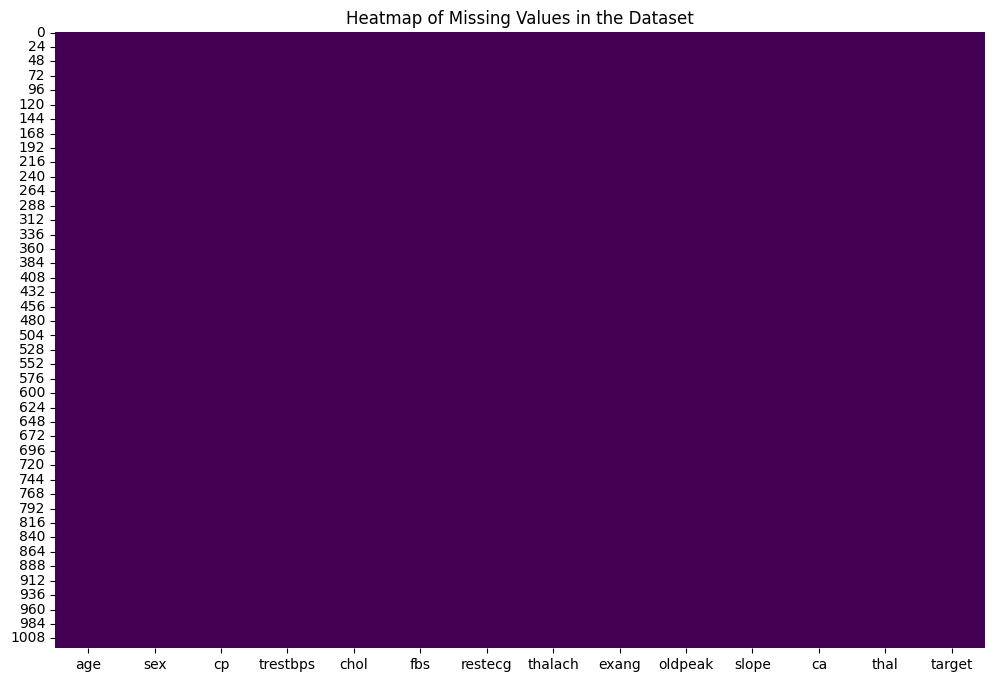

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
# Plotting the heatmap to visualize the data and the missing values
plt.figure(figsize=(12, 8))
sns.heatmap(heart_DF.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values in the Dataset')
plt.show()

#Checking for missing values
missing_values = heart_DF.isnull().sum()
print(missing_values)



The graph shows in purple the completed values and in yellow the lines with holes. The graph is completely purple, there is no missing values to deal with. We don't need to replace them with the method replace() or to delete them with dropna() from Pandas.

As we can see in the info, there is 1025 rows and we also have the type of value in the dataframe for each features. The data type for some columns are not matched and this can biased the model. We do not want categorical constraint with a numerical type

In [9]:
#List of numerical features
list_numerical = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

#List of categorical features
list_categorical = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Getting the two datasets separating the categorical and numerical features
num_heart_DF = heart_DF[list_numerical]

cat_heart_DF = heart_DF[list_categorical]

In [10]:
#Describing the data frame
print("Descriptive statistics of the data frame")
heart_DF.describe()

Descriptive statistics of the data frame


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Let's check for duplicate now

In [11]:
# Check for duplicate rows in the dataset
duplicated_rows = heart_DF.duplicated()

# Print the number of duplicated rows
num_duplicated_rows = duplicated_rows.sum()
print(f"Number of duplicated rows: {num_duplicated_rows}")

# If there are duplicated rows, print them
if num_duplicated_rows > 0:
    print("Duplicated rows:")
    print(heart_DF[duplicated_rows])

Number of duplicated rows: 723
Duplicated rows:
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  targ

It is a huge amount of duplicates. We need to remove them

In [12]:
# Remove duplicated rows from the dataset
heart_DF= heart_DF.drop_duplicates()


In [13]:
# Resuming the metadata of the data frame (number of non-null values, data type, memory usage)
print("Resume the data frame")
heart_DF.info()

Resume the data frame
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


The type of the categorical features needs to be changed to object :

In [14]:
#Updating the data type of the categorical features
heart_DF[list_categorical] = heart_DF[list_categorical].astype('object')
heart_DF.info()



<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    object 
 2   cp        302 non-null    object 
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    object 
 6   restecg   302 non-null    object 
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    object 
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    object 
 11  ca        302 non-null    int64  
 12  thal      302 non-null    object 
 13  target    302 non-null    int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 35.4+ KB


Doing some copies to process differently depending on the problem we want to solve (classification, regression or cluser)

In [15]:
heart_DF_regression = heart_DF.copy()
heart_DF_cluster = heart_DF.copy()

## 2. EXPLORATORY DATA ANALYSIS (EDA)

Are my classes balanced?

C:\Users\oliva\AppData\Local\Temp\ipykernel_30448\1988317469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_balance.index, y=target_balance.values, palette='viridis')


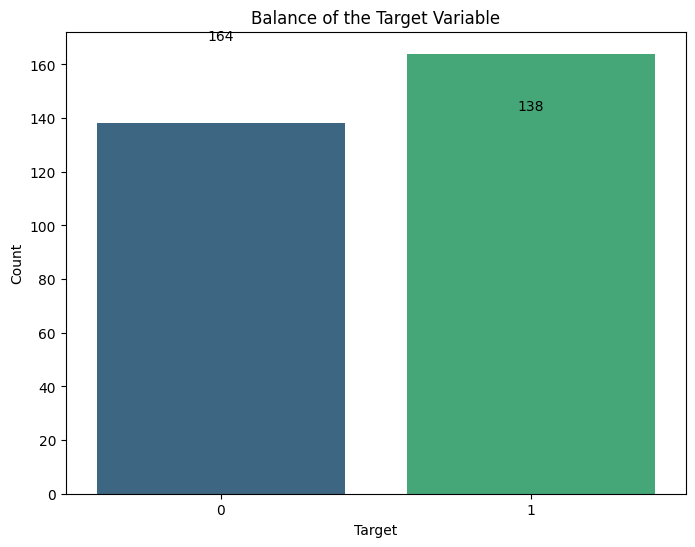

In [16]:
# Checking the balance of the target variable
target_balance = heart_DF['target'].value_counts()

# Plotting the balance of the target variable
# Creating a figure sized 8x6 inche (control the size of the plot)
plt.figure(figsize=(8, 6)) 
# Creating a bar plot with seaborn
ax = sns.barplot(x=target_balance.index, y=target_balance.values, palette='viridis')

# Adding the numbers on top of the bars
for i in range(len(target_balance)):
    ax.text(x=i, y=target_balance.values[i] + 5, s=str(target_balance.values[i]), ha='center')

# Adding labels and title
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Balance of the Target Variable')
plt.show()

The dataset is pretty well balanced (almost the same number of cases with and without the disease).

Correlation Matrix, useful for all the problem resolution

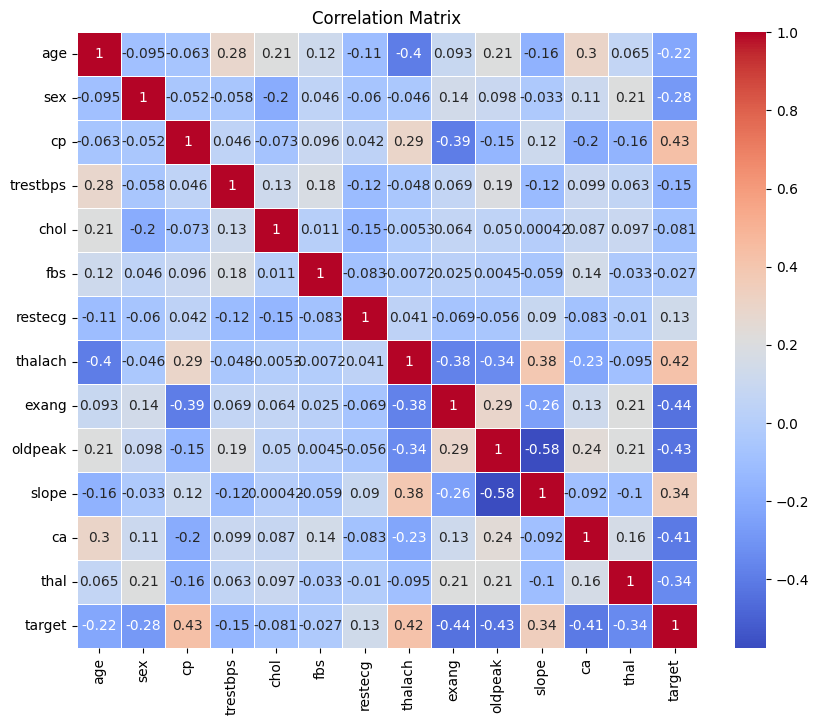

In [17]:
corr_matrix = heart_DF.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

### 2.1 EDA FOR CLASSIFICATION

NUMERICAL FEATURES ANALYSIS

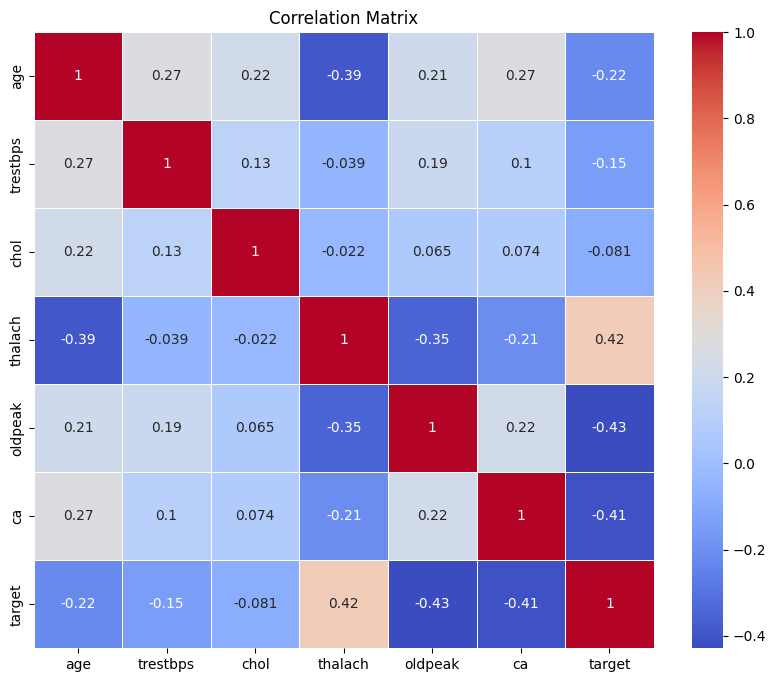

In [18]:
#Adding the target variable to the numerical features to have also how the target variable is correlated with the numerical features
# Calculate the correlation matrix
num_heart_DF_and_target = pd.concat([num_heart_DF, heart_DF['target']], axis=1)
corr_matrix = num_heart_DF_and_target.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Scatterplot to find some relevant non linear relation but nothing clear can be visualize

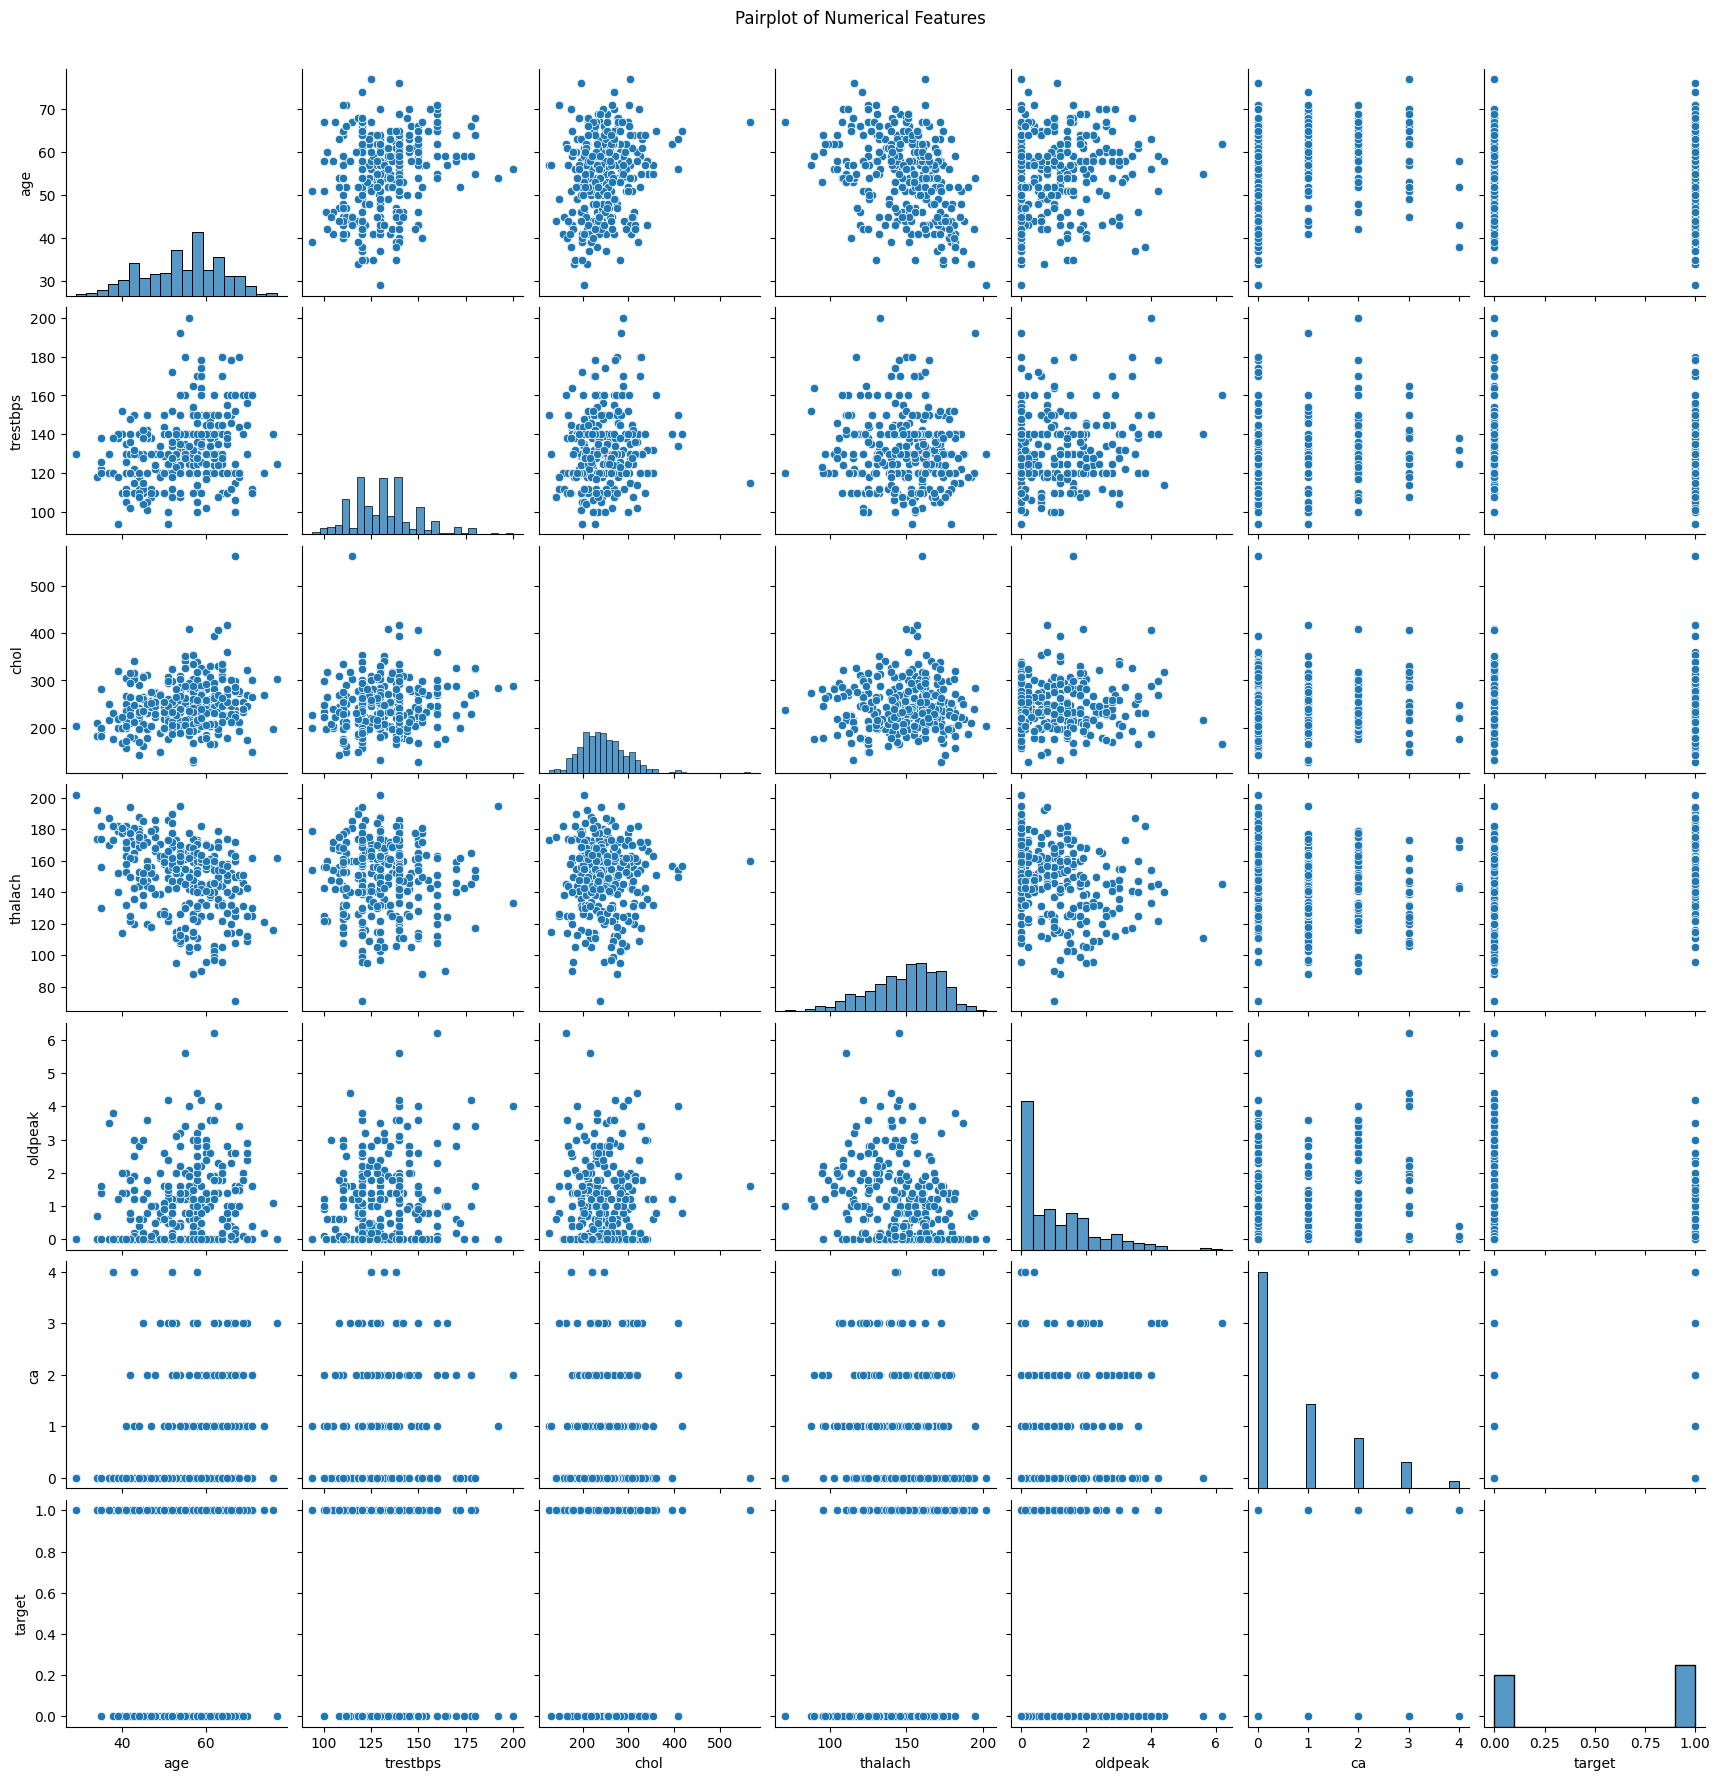

In [19]:
# Plotting pairplot for the numerical features to visualize the correlation
sns.pairplot(num_heart_DF_and_target)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

CATEGORICAL FEATURES ANALYSIS

Repartition of categorical features Analysis: Plotting various graphs to see how the categorical features are shared through the dataset. we are using several libraries such a matplotlib or seaborn (described above)

In [20]:
# Checking the number of male in the dataset
num_males = heart_DF['sex'].value_counts()[1]
num_females = 302 - num_males
print(f"Number of males in the dataset: {num_males}")
print(f"Number of females in the dataset: {num_females}")

Number of males in the dataset: 206
Number of females in the dataset: 96


In [21]:
# Calculate the number of men and women with heart disease
num_males_target_1 = heart_DF[(heart_DF['sex'] == 1) & (heart_DF['target'] == 1)].shape[0]
num_females_target_1 = heart_DF[(heart_DF['sex'] == 0) & (heart_DF['target'] == 0)].shape[0]
print(num_males_target_1)
# Calculate the percentage of men and women with heart disease
percentage_men_with_disease = (num_males_target_1 / num_males) * 100
percentage_women_with_disease = (num_females_target_1 / num_females) * 100

print(f"Percentage of men with heart disease: {percentage_men_with_disease:.2f}%")
print(f"Percentage of women with heart disease: {percentage_women_with_disease:.2f}%")

92
Percentage of men with heart disease: 44.66%
Percentage of women with heart disease: 25.00%


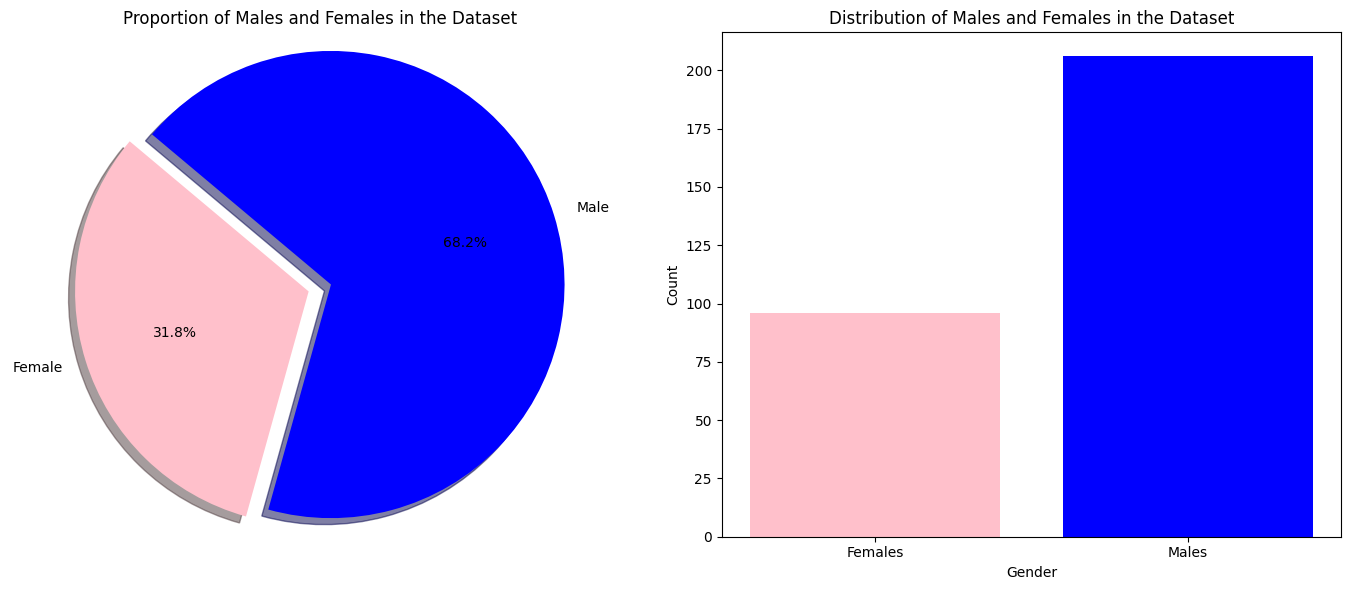

In [22]:


# Data repartition
labels = ['Female', 'Male']
sizes = [num_females, num_males]
colors = ['pink', 'blue']
explode = (0.1, 0)  # explode the 1st slice to separate the slices in the pie chart

# Creating subplots for 2 figures side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart with the proportion 
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].set_title('Proportion of Males and Females in the Dataset')
axs[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Histogram with the count
axs[1].bar(['Females', 'Males'], [num_females, num_males], color=['pink', 'blue'])
axs[1].set_xlabel('Gender')
axs[1].set_ylabel('Count')
axs[1].set_title('Distribution of Males and Females in the Dataset')

# Plot the figure
plt.tight_layout()
plt.show()

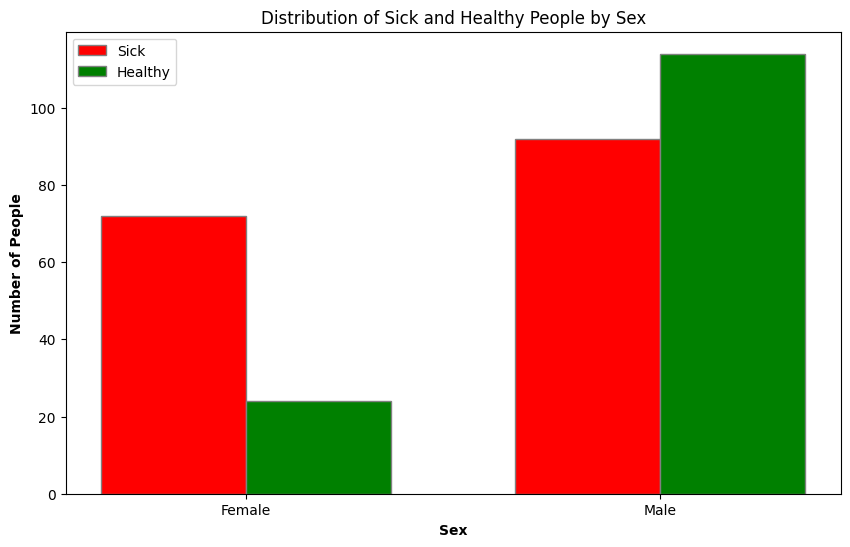

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Number of sick and healthy people for each sex
sex_target_0 = heart_DF[heart_DF['target'] == 0]['sex'].value_counts()
sex_target_1 = heart_DF[heart_DF['target'] == 1]['sex'].value_counts()

# Data for the histogram
labels = ['Female', 'Male']
sick = [sex_target_1[0], sex_target_1[1]]
healthy = [sex_target_0[0], sex_target_0[1]]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Sex', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Sex')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Chest pain analysis

In [24]:
# Calculate the number of persons with the disease for each chest pain type
cp_target_1 = heart_DF[heart_DF['target'] == 1]['cp'].value_counts()

# Calculate the total number of persons for each chest pain type
cp_total = heart_DF['cp'].value_counts()

# Calculate the percentage of persons with the disease for each chest pain type
cp_percentage = (cp_target_1 / cp_total) * 100

# Print the results
for cp_type in cp_percentage.index:
    print(f"Percentage of persons with chest pain type {cp_type} and heart disease: {cp_percentage[cp_type]:.2f}%")

Percentage of persons with chest pain type 0 and heart disease: 27.27%
Percentage of persons with chest pain type 1 and heart disease: 82.00%
Percentage of persons with chest pain type 2 and heart disease: 79.07%
Percentage of persons with chest pain type 3 and heart disease: 69.57%


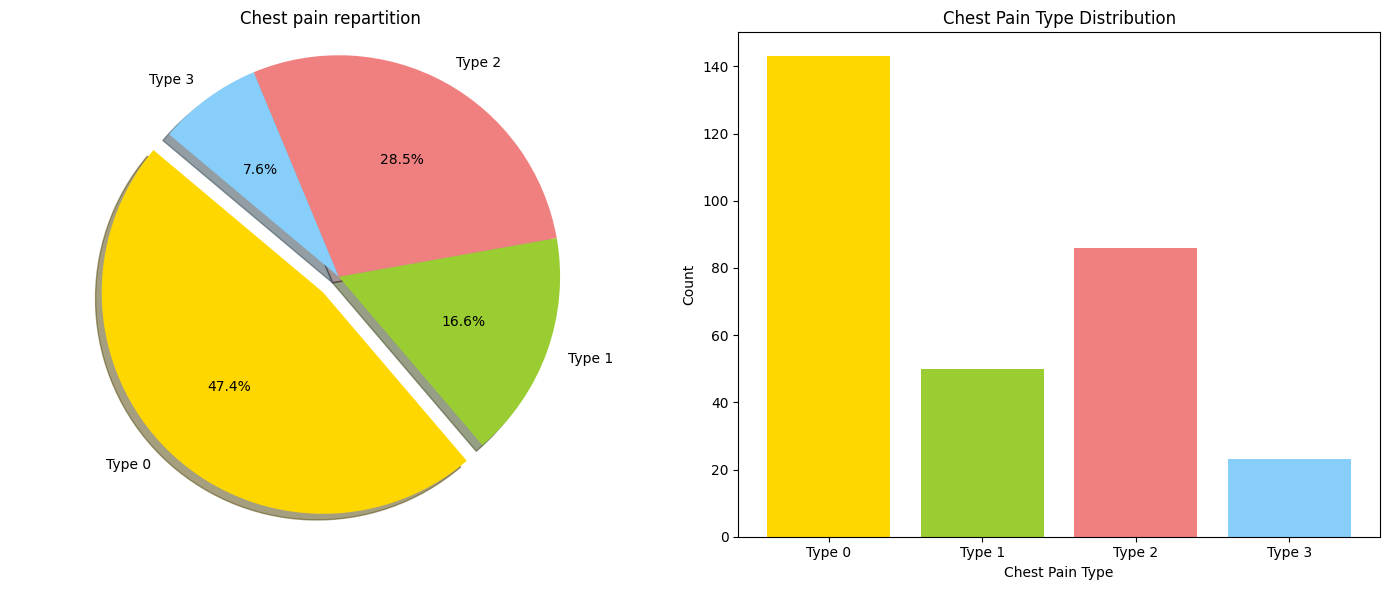

In [25]:
# Données pour le diagramme circulaire
labels = ['Type 0', 'Type 1', 'Type 2', 'Type 3']
sizes = [heart_DF['cp'].value_counts()[0], heart_DF['cp'].value_counts()[1], heart_DF['cp'].value_counts()[2], heart_DF['cp'].value_counts()[3]]
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0.1, 0, 0, 0)  # Mettre en évidence le premier segment

# Créer une figure avec deux sous-graphiques côte à côte
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Diagramme circulaire
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Assure que le pie chart est dessiné en cercle
axs[0].set_title('Chest pain repartition')

# Graphique à barres
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Chest Pain Type')
axs[1].set_ylabel('Count')
axs[1].set_title('Chest Pain Type Distribution')

# Afficher les graphiques
plt.tight_layout()
plt.show()

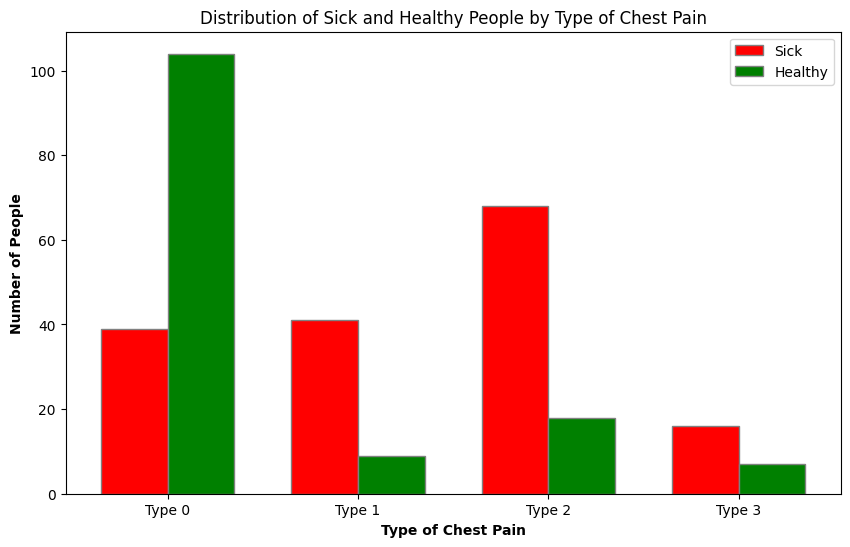

In [26]:

# Number of sick and healthy people for each type of chest pain
cp_target_0 = heart_DF[heart_DF['target'] == 0]['cp'].value_counts()
cp_target_1 = heart_DF[heart_DF['target'] == 1]['cp'].value_counts()

# Data for the histogram
labels = ['Type 0', 'Type 1', 'Type 2', 'Type 3']
sick = [cp_target_1[0], cp_target_1[1], cp_target_1[2], cp_target_1[3]]
healthy = [cp_target_0[0], cp_target_0[1], cp_target_0[2], cp_target_0[3]]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Type of Chest Pain', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Type of Chest Pain')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Percentage of persons with fasting blood sugar type 0 and heart disease: 54.86%
Percentage of persons with fasting blood sugar type 1 and heart disease: 51.11%


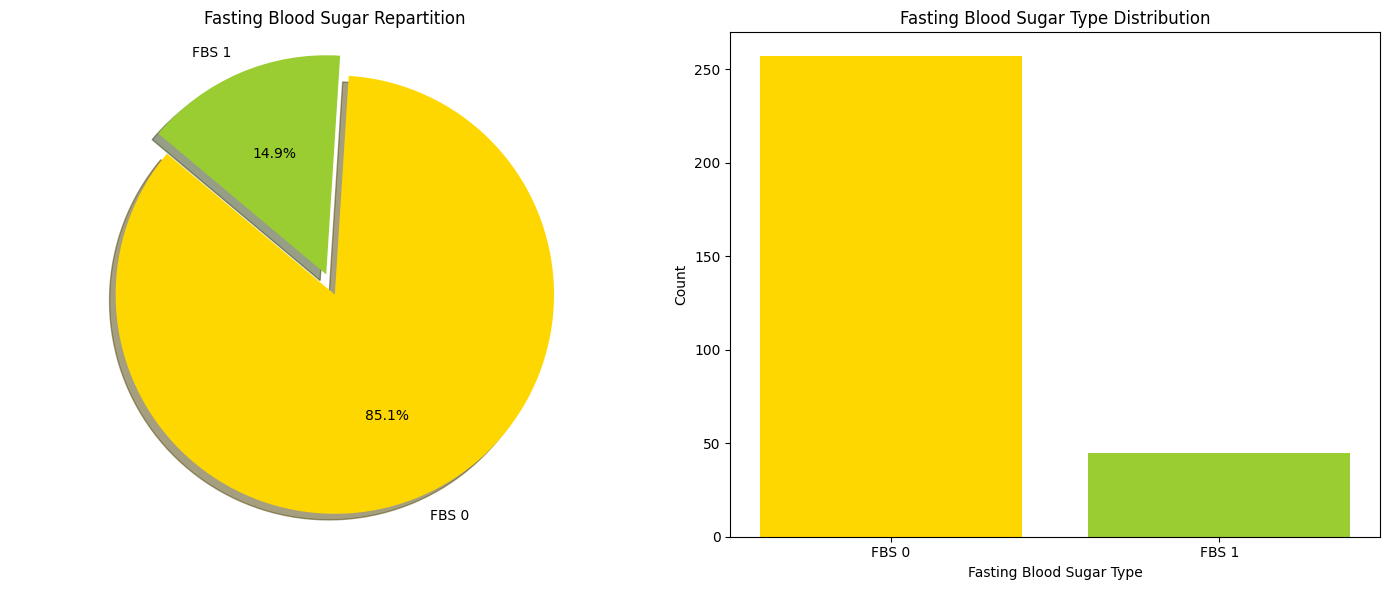

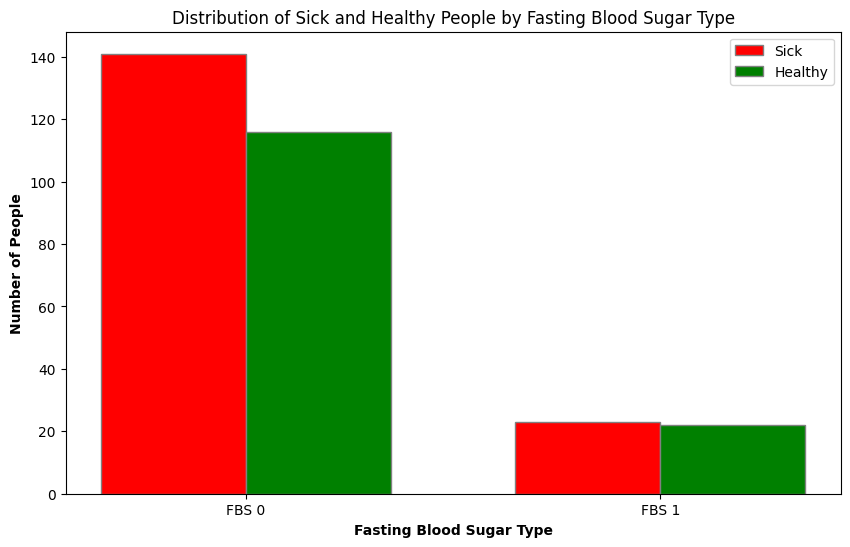

In [27]:
# Calculate the number of persons with the disease for each fasting blood sugar type
fbs_target_1 = heart_DF[heart_DF['target'] == 1]['fbs'].value_counts()

# Calculate the total number of persons for each fasting blood sugar type
fbs_total = heart_DF['fbs'].value_counts()

# Calculate the percentage of persons with the disease for each fasting blood sugar type
fbs_percentage = (fbs_target_1 / fbs_total) * 100

# Print the results
for fbs_type in fbs_percentage.index:
    print(f"Percentage of persons with fasting blood sugar type {fbs_type} and heart disease: {fbs_percentage[fbs_type]:.2f}%")

# Data for the pie chart
labels = ['FBS 0', 'FBS 1']
sizes = [heart_DF['fbs'].value_counts()[0], heart_DF['fbs'].value_counts()[1]]
colors = ['gold', 'yellowgreen']
explode = (0.1, 0)  # Explode the first slice

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Ensure that the pie chart is drawn as a circle
axs[0].set_title('Fasting Blood Sugar Repartition')

# Bar chart
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Fasting Blood Sugar Type')
axs[1].set_ylabel('Count')
axs[1].set_title('Fasting Blood Sugar Type Distribution')

# Show the plots
plt.tight_layout()
plt.show()

# Number of sick and healthy people for each type of fasting blood sugar
fbs_target_0 = heart_DF[heart_DF['target'] == 0]['fbs'].value_counts()
fbs_target_1 = heart_DF[heart_DF['target'] == 1]['fbs'].value_counts()

# Data for the histogram
labels = ['FBS 0', 'FBS 1']
sick = [fbs_target_1[0], fbs_target_1[1]]
healthy = [fbs_target_0[0], fbs_target_0[1]]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Fasting Blood Sugar Type', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Fasting Blood Sugar Type')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Percentage of persons with resting electrocardiographic result type 1 and heart disease: 62.91%
Percentage of persons with resting electrocardiographic result type 0 and heart disease: 46.26%
Percentage of persons with resting electrocardiographic result type 2 and heart disease: 25.00%


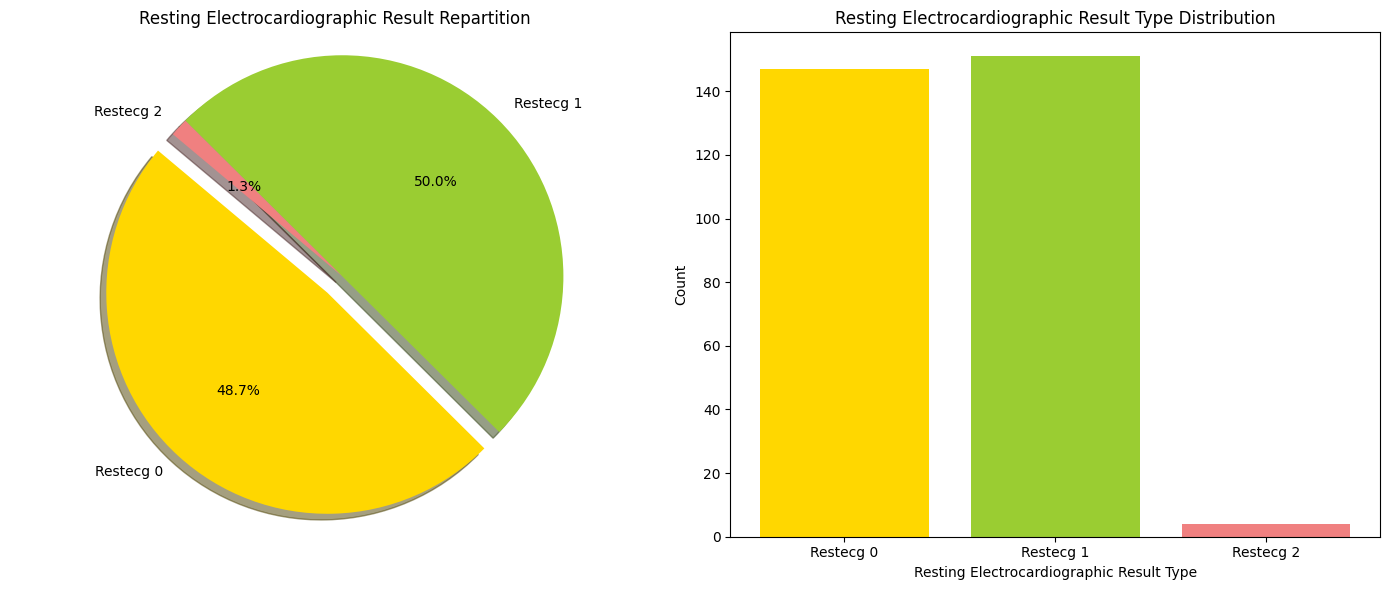

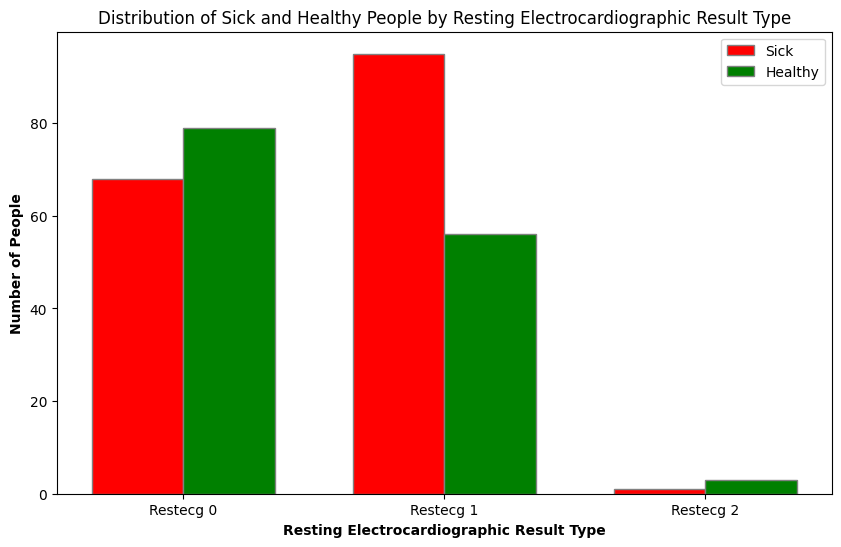

In [28]:
# Calculate the number of persons with the disease for each resting electrocardiographic result type
restecg_target_1 = heart_DF[heart_DF['target'] == 1]['restecg'].value_counts()

# Calculate the total number of persons for each resting electrocardiographic result type
restecg_total = heart_DF['restecg'].value_counts()

# Calculate the percentage of persons with the disease for each resting electrocardiographic result type
restecg_percentage = (restecg_target_1 / restecg_total) * 100

# Print the results
for restecg_type in restecg_percentage.index:
    print(f"Percentage of persons with resting electrocardiographic result type {restecg_type} and heart disease: {restecg_percentage[restecg_type]:.2f}%")

# Data for the pie chart
labels = ['Restecg 0', 'Restecg 1', 'Restecg 2']
sizes = [heart_DF['restecg'].value_counts()[0], heart_DF['restecg'].value_counts()[1], heart_DF['restecg'].value_counts()[2]]
colors = ['gold', 'yellowgreen', 'lightcoral']
explode = (0.1, 0, 0)  # Explode the first slice

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Ensure that the pie chart is drawn as a circle
axs[0].set_title('Resting Electrocardiographic Result Repartition')

# Bar chart
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Resting Electrocardiographic Result Type')
axs[1].set_ylabel('Count')
axs[1].set_title('Resting Electrocardiographic Result Type Distribution')

# Show the plots
plt.tight_layout()
plt.show()
# Number of sick and healthy people for each type of resting electrocardiographic result
restecg_target_0 = heart_DF[heart_DF['target'] == 0]['restecg'].value_counts()
restecg_target_1 = heart_DF[heart_DF['target'] == 1]['restecg'].value_counts()

# Data for the histogram
labels = ['Restecg 0', 'Restecg 1', 'Restecg 2']
sick = [restecg_target_1[0], restecg_target_1[1], restecg_target_1[2]]
healthy = [restecg_target_0[0], restecg_target_0[1], restecg_target_0[2]]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Resting Electrocardiographic Result Type', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Resting Electrocardiographic Result Type')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Percentage of persons with exercise induced angina type 0 and heart disease: 69.46%
Percentage of persons with exercise induced angina type 1 and heart disease: 23.23%


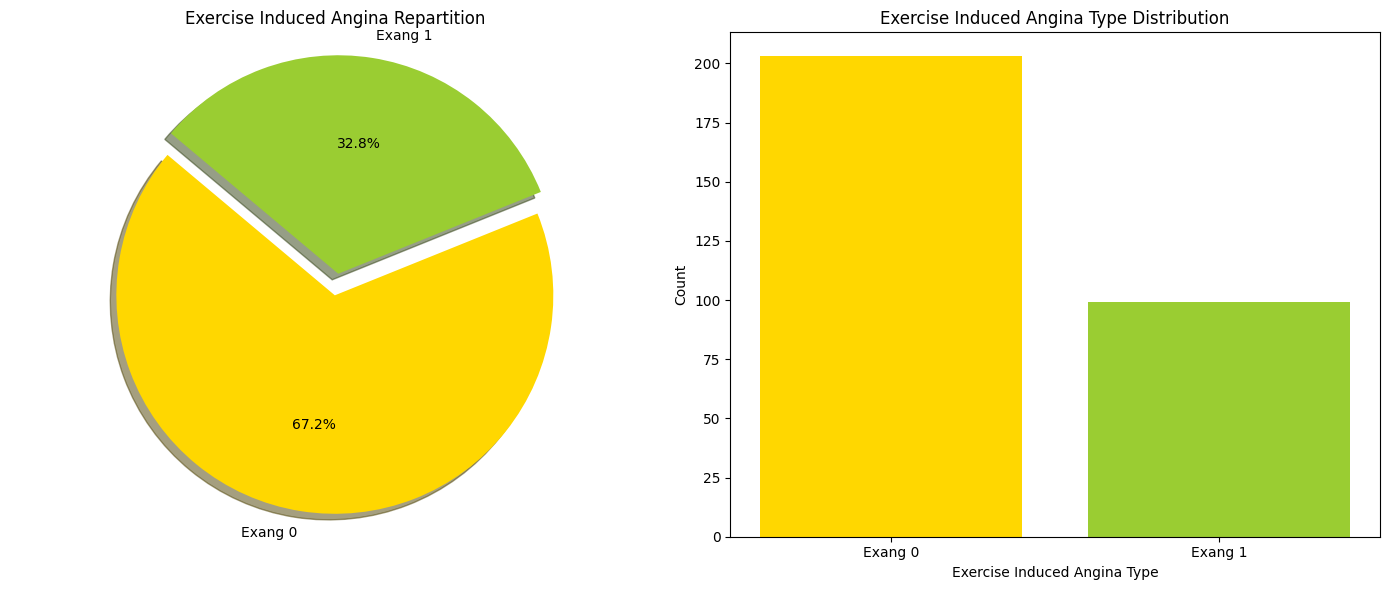

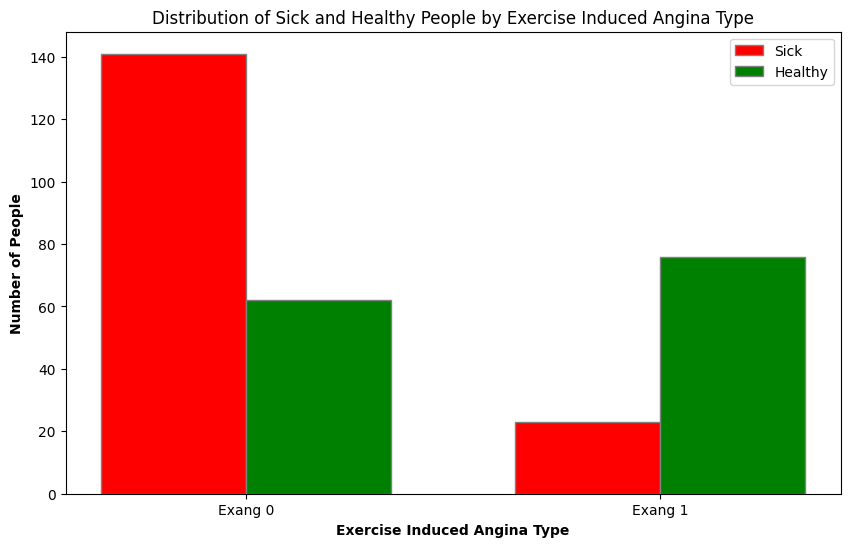

In [29]:
# Calculate the number of persons with the disease for each exercise induced angina type
exang_target_1 = heart_DF[heart_DF['target'] == 1]['exang'].value_counts()

# Calculate the total number of persons for each exercise induced angina type
exang_total = heart_DF['exang'].value_counts()

# Calculate the percentage of persons with the disease for each exercise induced angina type
exang_percentage = (exang_target_1 / exang_total) * 100

# Print the results
for exang_type in exang_percentage.index:
    print(f"Percentage of persons with exercise induced angina type {exang_type} and heart disease: {exang_percentage[exang_type]:.2f}%")

# Data for the pie chart
labels = ['Exang 0', 'Exang 1']
sizes = [heart_DF['exang'].value_counts()[0], heart_DF['exang'].value_counts()[1]]
colors = ['gold', 'yellowgreen']
explode = (0.1, 0)  # Explode the first slice

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Ensure that the pie chart is drawn as a circle
axs[0].set_title('Exercise Induced Angina Repartition')

# Bar chart
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Exercise Induced Angina Type')
axs[1].set_ylabel('Count')
axs[1].set_title('Exercise Induced Angina Type Distribution')

# Show the plots
plt.tight_layout()
plt.show()

# Number of sick and healthy people for each type of exercise induced angina
exang_target_0 = heart_DF[heart_DF['target'] == 0]['exang'].value_counts()
exang_target_1 = heart_DF[heart_DF['target'] == 1]['exang'].value_counts()

# Data for the histogram
labels = ['Exang 0', 'Exang 1']
sick = [exang_target_1[0], exang_target_1[1]]
healthy = [exang_target_0[0], exang_target_0[1]]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Exercise Induced Angina Type', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Exercise Induced Angina Type')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Percentage of persons with slope 2 and heart disease: 75.18%
Percentage of persons with slope 1 and heart disease: 35.00%
Percentage of persons with slope 0 and heart disease: 42.86%


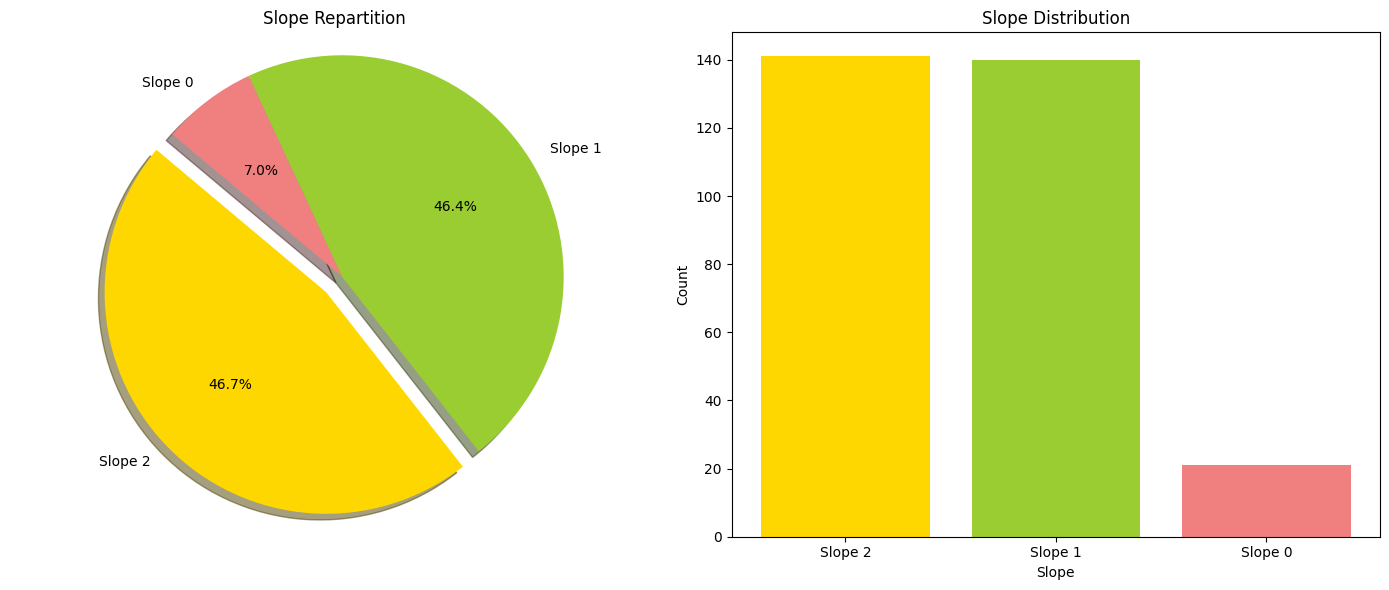

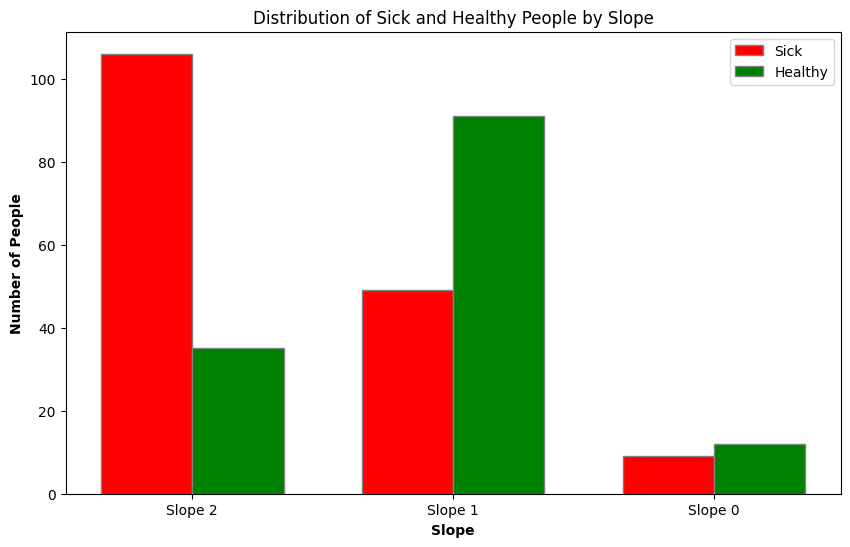

In [30]:


# Calculate the number of persons with the disease for each slope value
slope_target_1 = heart_DF[heart_DF['target'] == 1]['slope'].value_counts()

# Calculate the total number of persons for each slope value
slope_total = heart_DF['slope'].value_counts()

# Calculate the percentage of persons with the disease for each slope value
slope_percentage = (slope_target_1 / slope_total) * 100

# Print the results
for slope_type in slope_percentage.index:
    print(f"Percentage of persons with slope {slope_type} and heart disease: {slope_percentage[slope_type]:.2f}%")

# Data for the pie chart
labels = [f'Slope {i}' for i in slope_total.index]
sizes = slope_total.values
colors = ['gold', 'yellowgreen', 'lightcoral']
explode = (0.1, 0, 0)  # Explode the first slice

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Ensure that the pie chart is drawn as a circle
axs[0].set_title('Slope Repartition')

# Bar chart
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Slope')
axs[1].set_ylabel('Count')
axs[1].set_title('Slope Distribution')

# Show the plots
plt.tight_layout()
plt.show()

# Number of sick and healthy people for each slope value
slope_target_0 = heart_DF[heart_DF['target'] == 0]['slope'].value_counts()
slope_target_1 = heart_DF[heart_DF['target'] == 1]['slope'].value_counts()

# Data for the histogram
labels = [f'Slope {i}' for i in slope_total.index]
sick = [slope_target_1.get(i, 0) for i in slope_total.index]
healthy = [slope_target_0.get(i, 0) for i in slope_total.index]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Slope', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Slope')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Percentage of persons with 0 major vessels and heart disease: 74.29%
Percentage of persons with 1 major vessels and heart disease: 32.31%
Percentage of persons with 2 major vessels and heart disease: 18.42%
Percentage of persons with 3 major vessels and heart disease: 15.00%
Percentage of persons with 4 major vessels and heart disease: 75.00%


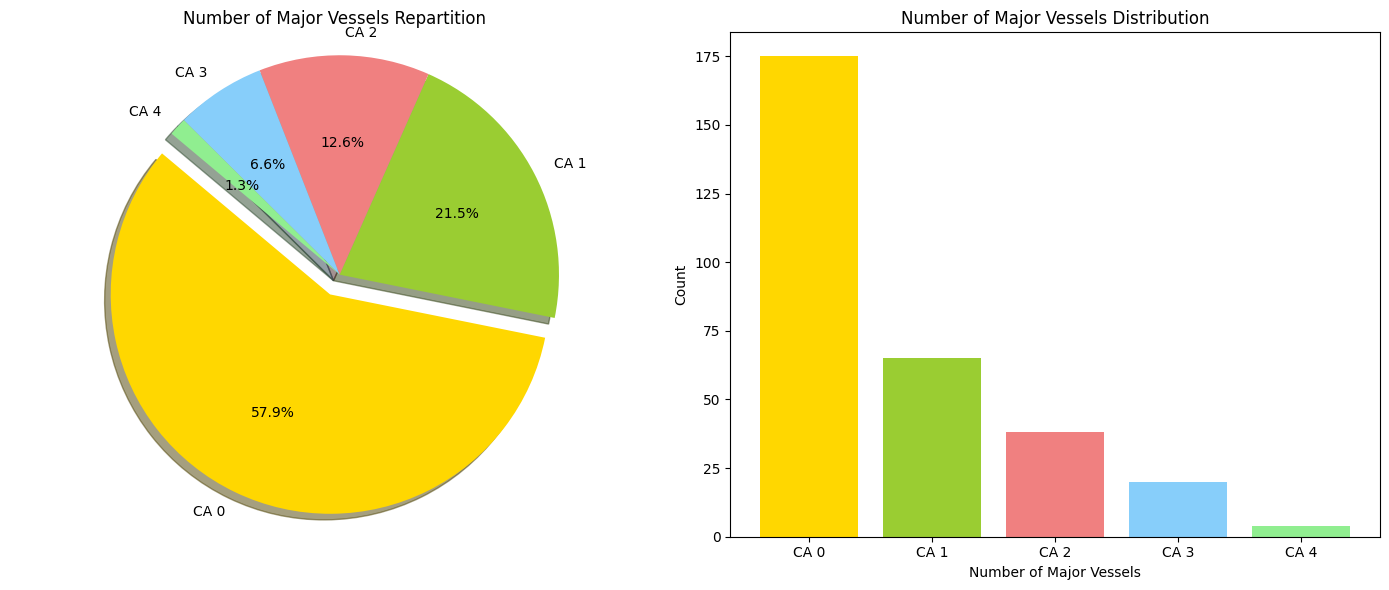

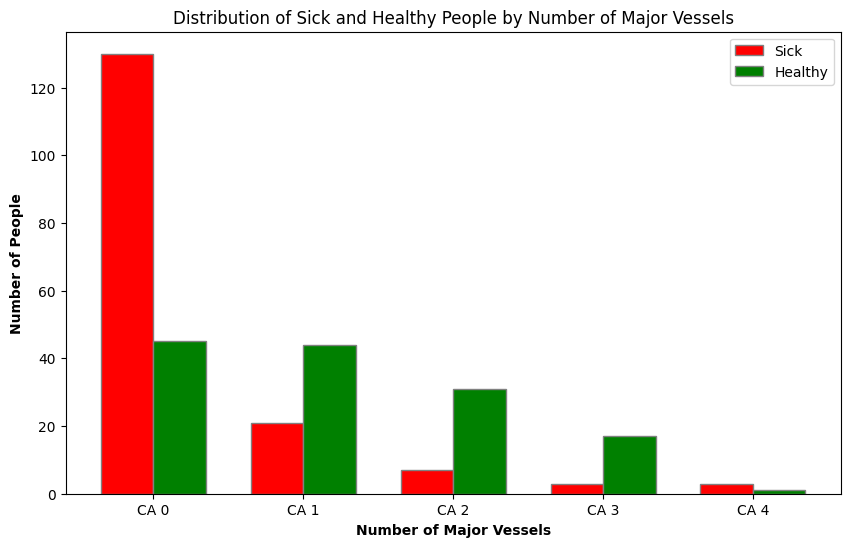

In [31]:
# Calculate the number of persons with the disease for each number of major vessels
ca_target_1 = heart_DF[heart_DF['target'] == 1]['ca'].value_counts()

# Calculate the total number of persons for each number of major vessels
ca_total = heart_DF['ca'].value_counts()

# Calculate the percentage of persons with the disease for each number of major vessels
ca_percentage = (ca_target_1 / ca_total) * 100

# Print the results
for ca_type in ca_percentage.index:
    print(f"Percentage of persons with {ca_type} major vessels and heart disease: {ca_percentage[ca_type]:.2f}%")

# Data for the pie chart
labels = [f'CA {i}' for i in ca_total.index]
sizes = ca_total.values
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue', 'lightgreen']
explode = (0.1, 0, 0, 0, 0)  # Explode the first slice

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Ensure that the pie chart is drawn as a circle
axs[0].set_title('Number of Major Vessels Repartition')

# Bar chart
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Number of Major Vessels')
axs[1].set_ylabel('Count')
axs[1].set_title('Number of Major Vessels Distribution')

# Show the plots
plt.tight_layout()
plt.show()

# Number of sick and healthy people for each number of major vessels
ca_target_0 = heart_DF[heart_DF['target'] == 0]['ca'].value_counts()
ca_target_1 = heart_DF[heart_DF['target'] == 1]['ca'].value_counts()

# Data for the histogram
labels = [f'CA {i}' for i in ca_total.index]
sick = [ca_target_1.get(i, 0) for i in ca_total.index]
healthy = [ca_target_0.get(i, 0) for i in ca_total.index]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Number of Major Vessels', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Number of Major Vessels')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Percentage of persons with thal type 2 and heart disease: 78.18%
Percentage of persons with thal type 3 and heart disease: 23.93%
Percentage of persons with thal type 1 and heart disease: 33.33%
Percentage of persons with thal type 0 and heart disease: 50.00%


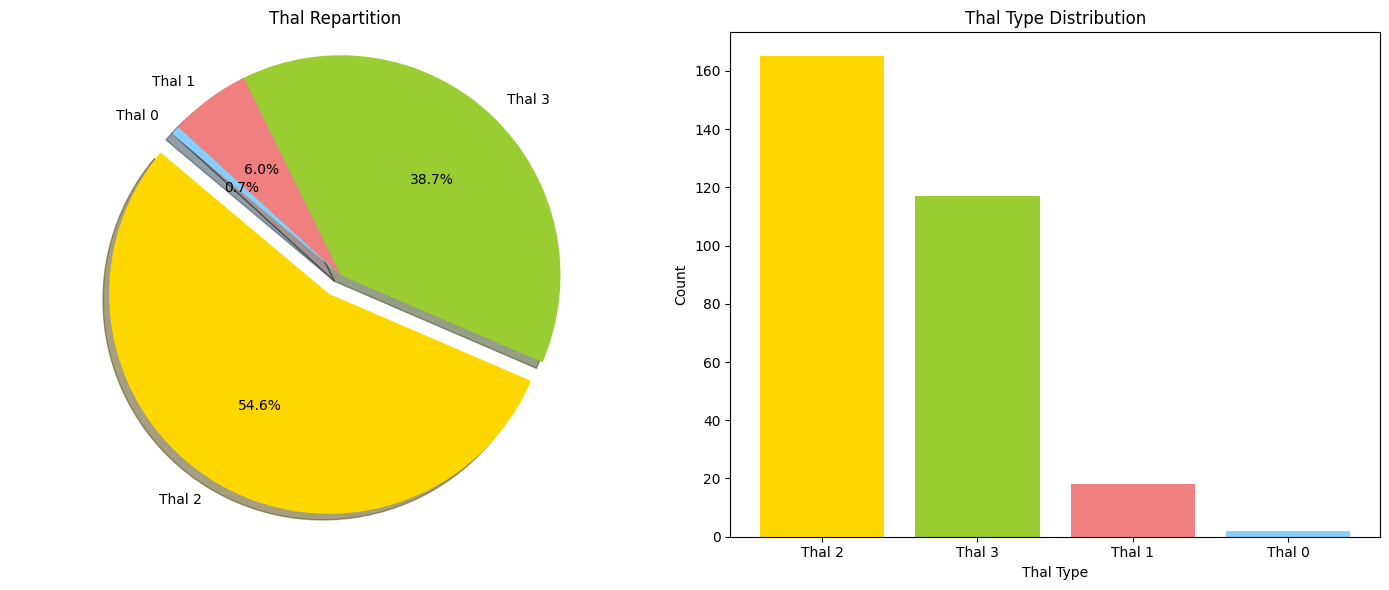

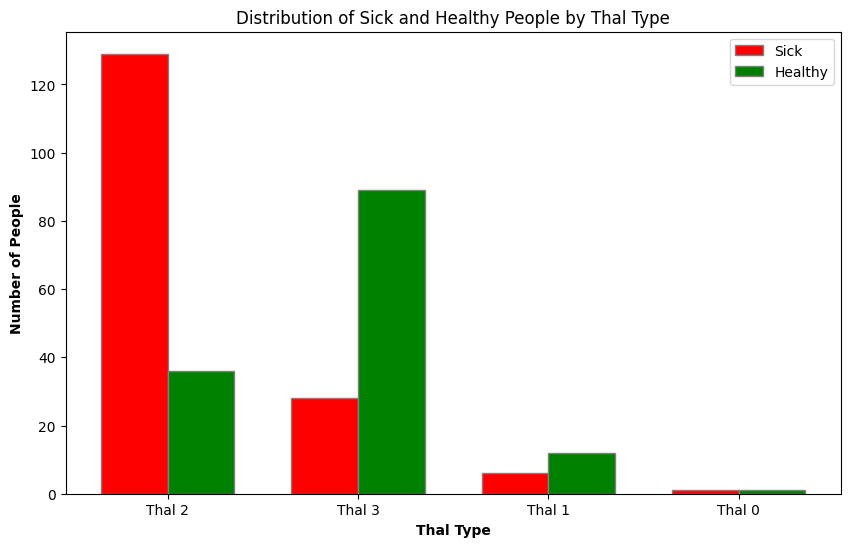

In [32]:
# Calculate the number of persons with the disease for each thal type
thal_target_1 = heart_DF[heart_DF['target'] == 1]['thal'].value_counts()

# Calculate the total number of persons for each thal type
thal_total = heart_DF['thal'].value_counts()

# Calculate the percentage of persons with the disease for each thal type
thal_percentage = (thal_target_1 / thal_total) * 100

# Print the results
for thal_type in thal_percentage.index:
    print(f"Percentage of persons with thal type {thal_type} and heart disease: {thal_percentage[thal_type]:.2f}%")

# Data for the pie chart
labels = [f'Thal {i}' for i in thal_total.index]
sizes = thal_total.values
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0.1, 0, 0, 0)  # Explode the first slice

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axs[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
axs[0].axis('equal')  # Ensure that the pie chart is drawn as a circle
axs[0].set_title('Thal Repartition')

# Bar chart
axs[1].bar(labels, sizes, color=colors)
axs[1].set_xlabel('Thal Type')
axs[1].set_ylabel('Count')
axs[1].set_title('Thal Type Distribution')

# Show the plots
plt.tight_layout()
plt.show()

# Number of sick and healthy people for each type of thal
thal_target_0 = heart_DF[heart_DF['target'] == 0]['thal'].value_counts()
thal_target_1 = heart_DF[heart_DF['target'] == 1]['thal'].value_counts()

# Data for the histogram
labels = [f'Thal {i}' for i in thal_total.index]
sick = [thal_target_1.get(i, 0) for i in thal_total.index]
healthy = [thal_target_0.get(i, 0) for i in thal_total.index]

# Bar width
bar_width = 0.35

# Bar positions
r1 = np.arange(len(labels))
r2 = [x + bar_width for x in r1]

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bars
plt.bar(r1, sick, color='red', width=bar_width, edgecolor='grey', label='Sick')
plt.bar(r2, healthy, color='green', width=bar_width, edgecolor='grey', label='Healthy')

# Add labels and title
plt.xlabel('Thal Type', fontweight='bold')
plt.ylabel('Number of People', fontweight='bold')
plt.title('Distribution of Sick and Healthy People by Thal Type')
plt.xticks([r + bar_width/2 for r in range(len(labels))], labels)

# Add legend
plt.legend()

# Show the plot
plt.show()

Chi-2 Test to select categorical features

In [33]:
target = 'target'
# Storage of the results
chi2_results = []


# loop on each categorical variable
for cat_var in list_categorical:
    print(f"Testing association between {cat_var} and {target}:")
    
    # Contingence table
    contingency_table = pd.crosstab(heart_DF[cat_var], heart_DF[target])
    
    # Chi2 test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Enregistrement des résultats
    chi2_results.append({
        'Variable': cat_var,
        'Chi2': chi2,
        'P-Value': p,
        'Degrees of Freedom': dof
    })
    
    # Affichage des résultats
    print(f"Chi2: {chi2:.4f}, P-Value: {p:.4f}, Degrees of Freedom: {dof}")
    print("")

# Convert results into df for a better visualization
chi2_df = pd.DataFrame(chi2_results)

# Filter significant variables
significant_vars = chi2_df
print("\nFeature significatively associated to target :")
print(significant_vars)

Testing association between sex and target:
Chi2: 23.0839, P-Value: 0.0000, Degrees of Freedom: 1

Testing association between cp and target:
Chi2: 80.9788, P-Value: 0.0000, Degrees of Freedom: 3

Testing association between fbs and target:
Chi2: 0.0924, P-Value: 0.7611, Degrees of Freedom: 1

Testing association between restecg and target:
Chi2: 9.7297, P-Value: 0.0077, Degrees of Freedom: 2

Testing association between exang and target:
Chi2: 55.4562, P-Value: 0.0000, Degrees of Freedom: 1

Testing association between slope and target:
Chi2: 46.8895, P-Value: 0.0000, Degrees of Freedom: 2

Testing association between thal and target:
Chi2: 84.6103, P-Value: 0.0000, Degrees of Freedom: 3


Feature significatively associated to target :
  Variable       Chi2       P-Value  Degrees of Freedom
0      sex  23.083879  1.550855e-06                   1
1       cp  80.978762  1.892684e-17                   3
2      fbs   0.092408  7.611375e-01                   1
3  restecg   9.729682  7.7130

NUMERICAL FEATURES : Analysis of Numerical features, their distribution and how they are related to the target variable 

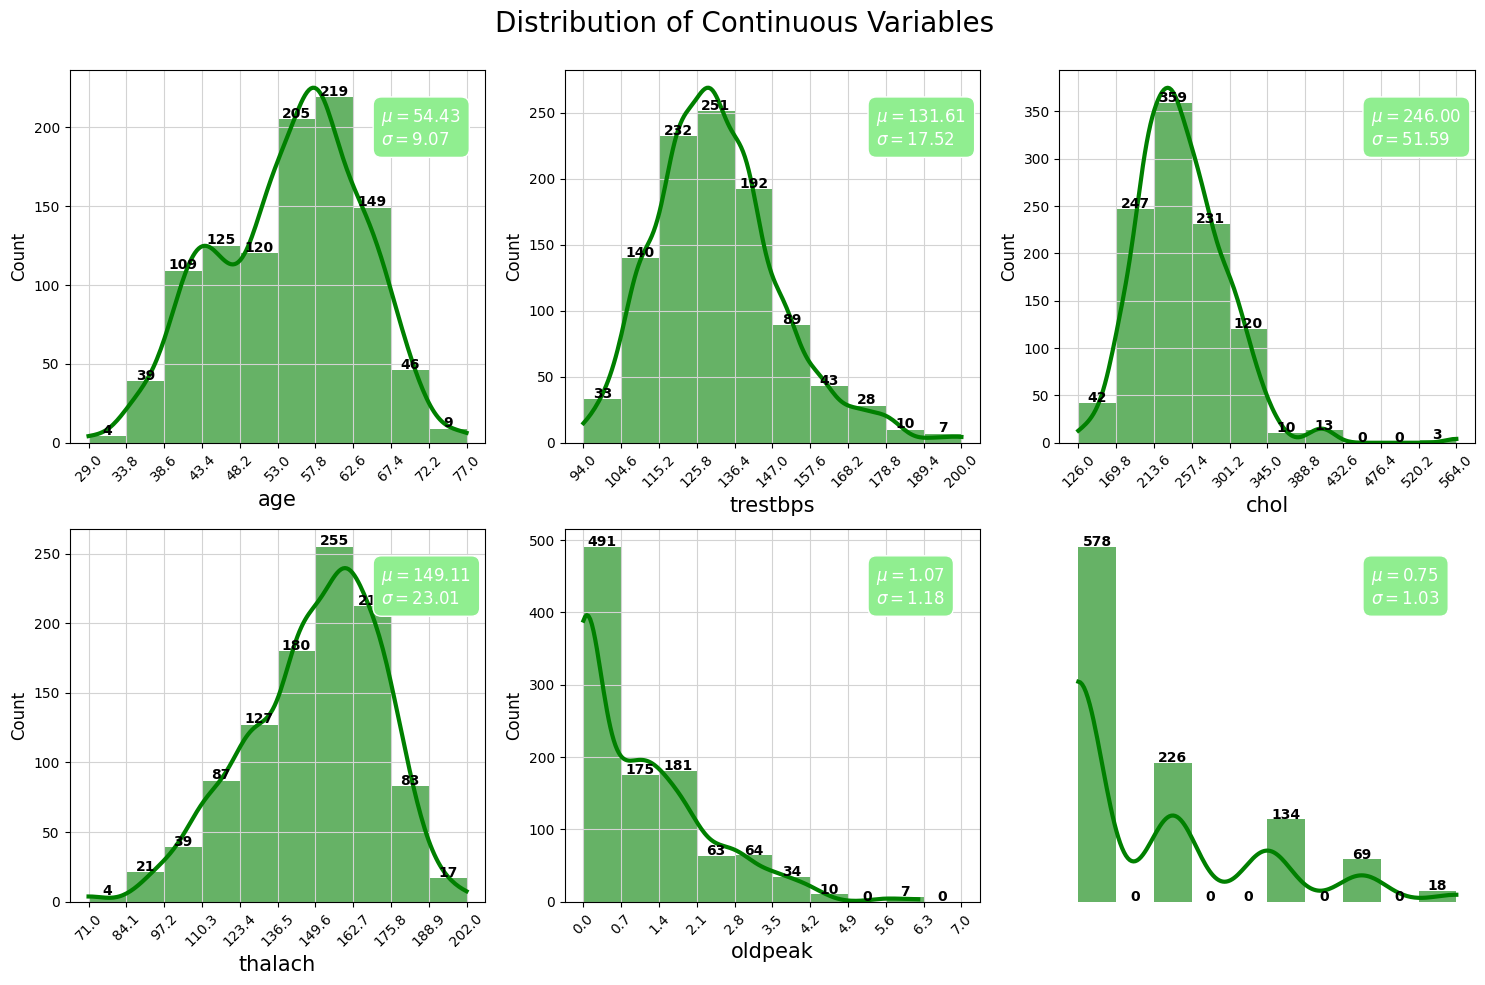

In [34]:
# Filter out continuous features for the univariate analysis
# Set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(num_heart_DF.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(num_heart_DF[col], 
                                     range=(np.floor(num_heart_DF[col].min()), np.ceil(num_heart_DF[col].max())))
    
    graph = sns.histplot(data=num_heart_DF, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='green', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')
    
    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")
    
    textstr = '\n'.join((
        r'$\mu=%.2f$' % num_heart_DF[col].mean(),
        r'$\sigma=%.2f$' % num_heart_DF[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#90EE90', edgecolor='white', pad=0.5))

ax[1,2].axis('off')
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [35]:
sns.set_palette(['#ff826e', 'red'])


#Adding the target column to the numerical features dataset
num_heart_DF_t = num_heart_DF.copy()
num_heart_DF_t['target'] = heart_DF['target']


num_heart_DF_t.head()



,age,trestbps,chol,thalach,oldpeak,ca,target
0,52,125,212,168,1.0,2,0.0
1,53,140,203,155,3.1,0,0.0
2,70,145,174,125,2.6,0,0.0
3,61,148,203,161,0.0,1,0.0
4,62,138,294,106,1.9,3,0.0


C:\Users\oliva\AppData\Local\Temp\ipykernel_30448\3255454171.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=num_heart_DF_t, x="target", y=col, ax=ax[i, 0], palette=['green', 'lightcoral'])
C:\Users\oliva\AppData\Local\Temp\ipykernel_30448\3255454171.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=num_heart_DF_t, x="target", y=col, ax=ax[i, 0], palette=['green', 'lightcoral'])
C:\Users\oliva\AppData\Local\Temp\ipykernel_30448\3255454171.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=num_hea

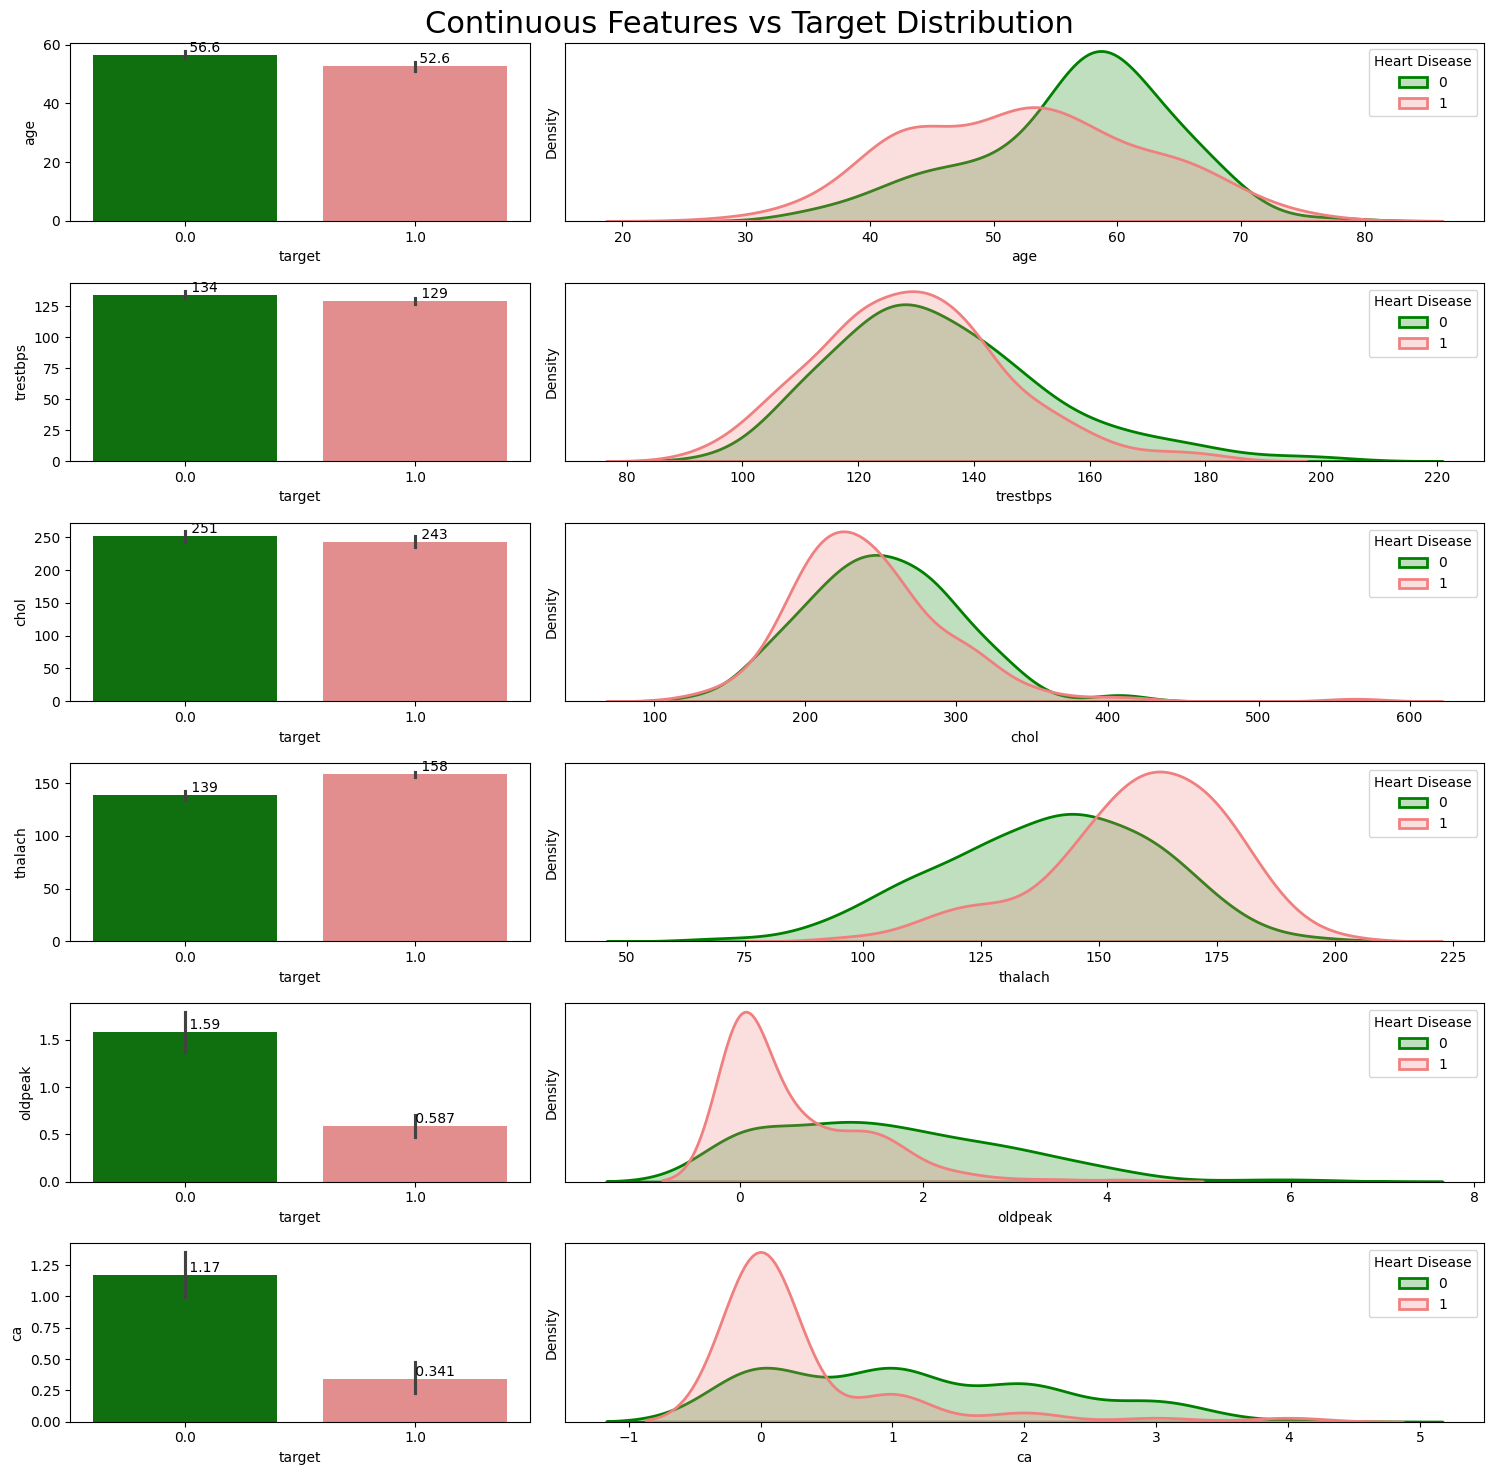

In [36]:
# Create the subplots
fig, ax = plt.subplots(len(list_numerical), 2, figsize=(15,15), gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and kde plots
for i, col in enumerate(list_numerical):
    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=num_heart_DF_t, x="target", y=col, ax=ax[i, 0], palette=['green', 'lightcoral'])
    
    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=num_heart_DF_t[num_heart_DF_t["target"]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0', color= 'green')
    sns.kdeplot(data=num_heart_DF_t[num_heart_DF_t["target"]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1', color= 'lightcoral')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='Heart Disease', loc='upper right')
    
    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')
        
# Set the title for the entire figure
plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()                     
plt.show()

### 2.2 K-MEAN Clusterization

Clusterization to undersand more how the numerical features are distributed

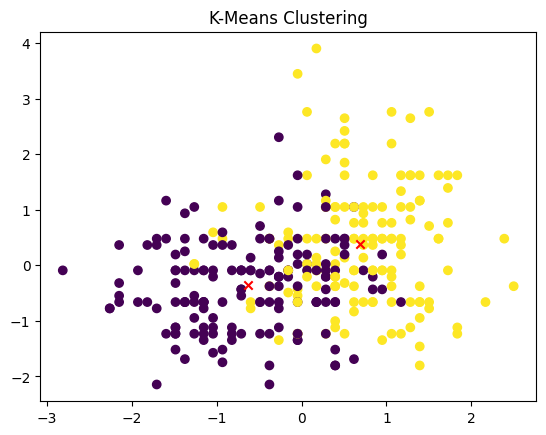

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
cluster_num = heart_DF_cluster[list_numerical]
cluster_num.head()
scaler = StandardScaler()
cluster_num_scaled = scaler.fit_transform(cluster_num)

# K-MX.means
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(cluster_num_scaled)

# Results
labels = kmeans.labels_  # Cluster assigned for each point
centroids = kmeans.cluster_centers_

# Visualisation
plt.scatter(cluster_num_scaled[:, 0], cluster_num_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')
plt.title("K-Means Clustering")
plt.show()


In [38]:
cluster_num_scaled_df = pd.DataFrame(cluster_num_scaled, columns=cluster_num.columns)
cluster_num_scaled_df['cluster'] = labels
cluster_summary = cluster_num_scaled_df.groupby('cluster').mean()
print(cluster_summary)

              age  trestbps      chol   thalach   oldpeak        ca
cluster                                                            
0       -0.626007 -0.350928 -0.217554  0.494086 -0.433401 -0.494512
1        0.686869  0.385047  0.238705 -0.542122  0.475537  0.542589


In [39]:

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_means_original = pd.DataFrame(centroids, columns=cluster_num.columns)
print(cluster_means_original)

         age    trestbps        chol     thalach   oldpeak        ca
0  48.765823  125.449367  235.259494  160.867089  0.540506  0.221519
1  60.625000  138.354167  258.833333  137.173611  1.594444  1.263889


### Data post-processing for classification

Handling the outliers (except ca) with the box-cox transformation

In [40]:
heart_DF = heart_DF.drop(columns= 'fbs')

In [41]:
num_heart_DF = heart_DF[list_numerical]
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for each feature
Q1 = num_heart_DF.quantile(0.25)
Q3 = num_heart_DF.quantile(0.75)

# Compute the IQR for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify the outliers for each feature
outliers = ((num_heart_DF < lower_bound) | (num_heart_DF > upper_bound)).sum()
outliers

age          0
trestbps     9
chol         5
thalach      1
oldpeak      5
ca          24
dtype: int64

ONE HOT ENCODING

In [42]:
# One-hot encode the specified columns
cp_encoded = pd.get_dummies(heart_DF['cp'], prefix='cp', drop_first=True)
thal_encoded = pd.get_dummies(heart_DF['thal'], prefix='thal', drop_first=True)
restecg_encoded = pd.get_dummies(heart_DF['restecg'], prefix='restecg', drop_first=True)

# Concatenate the one-hot encoded columns with the original dataframe
heart_DF = pd.concat([heart_DF, cp_encoded, thal_encoded, restecg_encoded], axis=1)

# Drop the original columns that have been one-hot encoded
heart_DF.drop(['cp', 'thal', 'restecg'], axis=1, inplace=True)

# Display the updated dataframe
heart_DF.head()


,age,sex,trestbps,chol,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,restecg_1,restecg_2
0,52,1,125,212,168,0,1.0,2,2,0,False,False,False,False,False,True,True,False
1,53,1,140,203,155,1,3.1,0,0,0,False,False,False,False,False,True,False,False
2,70,1,145,174,125,1,2.6,0,0,0,False,False,False,False,False,True,True,False
3,61,1,148,203,161,0,0.0,2,1,0,False,False,False,False,False,True,True,False
4,62,0,138,294,106,0,1.9,1,3,0,False,False,False,False,True,False,True,False



## 2.3 EDA FOR REGRESSION

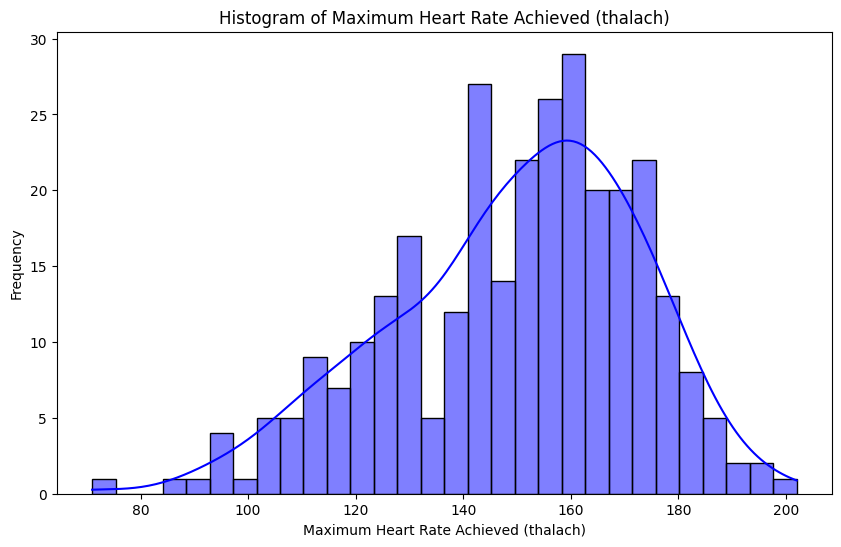

In [43]:
heart_DF_regression.head()
plt.figure(figsize=(10, 6))
sns.histplot(heart_DF_regression['thalach'], bins=30, kde=True, color='blue')
plt.title('Histogram of Maximum Heart Rate Achieved (thalach)')
plt.xlabel('Maximum Heart Rate Achieved (thalach)')
plt.ylabel('Frequency')
plt.show()

In [44]:
# Calculate the correlation matrix
corr_matrix_reg = heart_DF_regression.corr()

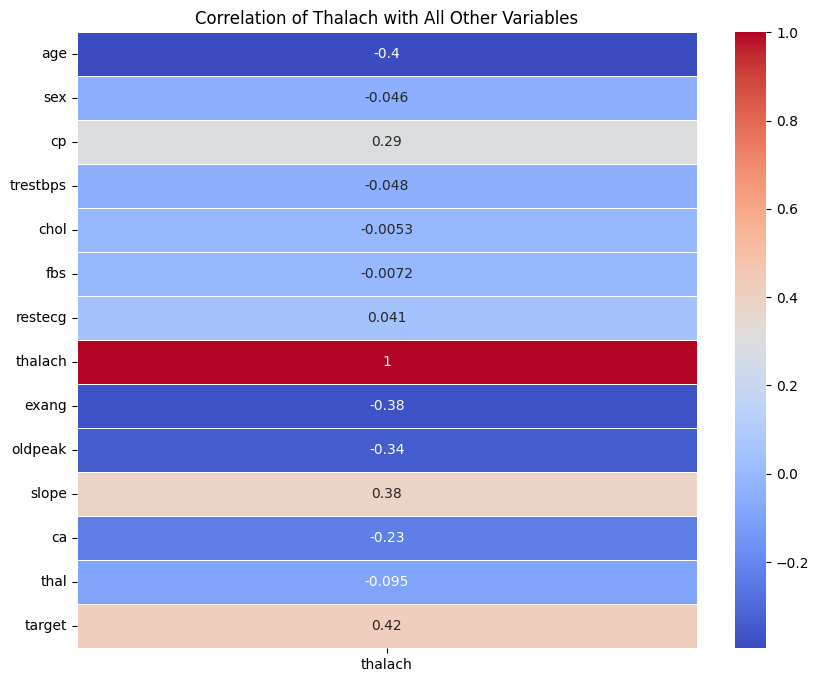

In [45]:
# Plot the heatmap for 'thalach' correlation with all other variables
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_reg[['thalach']], annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation of Thalach with All Other Variables')
plt.show()

In [46]:

# limit for  "thalach"
Q1_thalach = heart_DF_regression['thalach'].quantile(0.25)
Q3_thalach = heart_DF_regression['thalach'].quantile(0.75)
IQR_thalach = Q3_thalach - Q1_thalach

lower_bound_thalach = Q1_thalach - 1.5 * IQR_thalach
upper_bound_thalach = Q3_thalach + 1.5 * IQR_thalach
print(f"Lower bound for thalach: {lower_bound_thalach}")
print(f"Upper bound for thalach: {upper_bound_thalach}")
print(f"Size before : {heart_DF_regression.shape[0]}")
heart_DF_regression2 = heart_DF_regression[
    (heart_DF_regression['thalach'] >= lower_bound_thalach) &
    (heart_DF_regression['thalach'] <= upper_bound_thalach)
]
print(f"Size after : {heart_DF_regression2.shape[0]}")

Lower bound for thalach: 84.125
Upper bound for thalach: 215.125
Size before : 302
Size after : 301


In [47]:
#heart_DF_regression2[list_numerical] = MinMaxScaler().fit_transform(heart_DF_regression2[list_numerical])

# Transform final_df_reg into a DataFrame
final_df_reg = pd.DataFrame(heart_DF_regression2, columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'])

# Display the updated DataFrame
final_df_reg.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [48]:
# One-hot encode the specified columns
cp_encoded = pd.get_dummies(final_df_reg['cp'], prefix='cp', drop_first=True)
thal_encoded = pd.get_dummies(final_df_reg['thal'], prefix='thal', drop_first=True)
restecg_encoded = pd.get_dummies(final_df_reg['restecg'], prefix='restecg', drop_first=True)

# Concatenate the one-hot encoded columns with the original dataframe
final_df_reg = pd.concat([final_df_reg, cp_encoded, thal_encoded, restecg_encoded], axis=1)

# Drop the original columns that have been one-hot encoded
final_df_reg.drop(['cp', 'thal', 'restecg'], axis=1, inplace=True)

# Display the updated dataframe
final_df_reg.head()
list_numerical_without_thalach = [feature for feature in list_numerical if feature != 'thalach']

## 3. MODEL EVALUATION AND VALIDATION FOR CLASSIFICATION

In [49]:
x = heart_DF.drop(['target'], axis=1)
y = heart_DF['target']

In [50]:
# --- Data Normalization using Min-Max Method ---
x = MinMaxScaler().fit_transform(x)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)

As we are going to try different models, I decided to do a function to choose the best hyperparameters from each models. This function selects the "best" hyperparameters depending on which model validation metric we want to have. We can choose this metric as an argument.

In [52]:
## Also tried to do directly nested validation but it was not working. I kept the code here 




#cv_outer = KFold(n_splits=7, shuffle=True, random_state=0)
#outer_results_rec = []
#outer_results_acc = []
#y_true = []  # Vrai labels des données test pour tous les plis
#y_pred = []  # Prédictions pour tous les plis
#for train_ix, test_ix in cv_outer.split(x):
#    X_train, X_test = x[train_ix], x[test_ix]
#    y_train, y_test = y.iloc[train_ix], y.iloc[test_ix]
#
#    cv_inner = KFold(n_splits=3, shuffle=True, random_state=0)
#
#    dt_base = DecisionTreeClassifier(random_state=0)
#
#    # Hyperparameter grid for DT
#    param_grid_dt = {
#        'criterion': ['gini', 'entropy'],
#        'max_depth': [2,3],
#        'min_samples_split': [2, 3, 4],
#        'min_samples_leaf': [1, 2]
#    }
#
#    search = GridSearchCV(dt_base, param_grid_dt, scoring='recall', cv=cv_inner, refit=True)
#
#    result = search.fit(X_train, y_train)
#
#    best_model = result.best_estimator_
#
#    yhat = best_model.predict(X_test)
#    y_true.extend(y_test)
#    y_pred.extend(yhat)
#
#    acc = accuracy_score(y_test, yhat)
#    rec = recall_score(y_test, yhat)
#
#    # Store the result
#    outer_results_rec.append(rec)
#    outer_results_acc.append(acc)
#    print(f"Fold Recall: {rec:.3f}, Best Params: {result.best_params_}")
#print(f"Mean Recall: {np.mean(outer_results_rec):.3f} +/- {np.std(outer_results_rec):.3f}")
#print(classification_report(y_true, y_pred))

In [53]:
# function to find the best hyperparameters for a given classifier through the training data
def classifier_hyperparameters(classifier, param_grid, X_train, y_train, scoring='recall', n_splits=3):

    # Create a StratifiedKFold object for cross-validation, ensuring that the class distribution 
    # is preserved across all the folds.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    # Initialize a GridSearchCV object to perform an exhaustive search over the parameter grid.
    # The 'cv' parameter specifies the cross-validation strategy, and the 'scoring' parameter 
    # determines the metric used to evaluate model performance during hyperparameter tuning.
    classifier_grid = GridSearchCV(classifier, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    # Train the GridSearchCV object on the training data. This will evaluate all parameter 
    # combinations in the grid using the specified cross-validation strategy.
    classifier_grid.fit(X_train, y_train)

    # Extract the best combination of hyperparameters identified during the grid search.
    best_hyperparameters = classifier_grid.best_params_

    # Return the best fitted model (`best_estimator_`) and the optimal hyperparameters.
    # The best fitted model is trained using the entire training dataset and the optimal parameters.
    return classifier_grid.best_estimator_, best_hyperparameters


## DECISION TREE

In [54]:
#Decision Tree Classifier

# Create the base model
dt_base = DecisionTreeClassifier(random_state=0)

# Hyperparameter grid for DT
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3, None],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

best_dt, best_hyperparameters_dt = classifier_hyperparameters(dt_base, param_grid_dt, X_train, y_train) 

print(f"Best Hyperparameters for Decision Tree: {best_hyperparameters_dt}")
print(f"Best Decision Tree Model: {best_dt}")

Best Hyperparameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree Model: DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


In [55]:
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)
print("REPORT CLASSIFICATION DECISION TREE ON THE TEST DATASET")
print(classification_report(y_test, y_pred_dt))

print("REPORT CLASSIFICATION DECISION TREE ON THE TRAINED DATASET")
print(classification_report(y_train, best_dt.predict(X_train)))



REPORT CLASSIFICATION DECISION TREE ON THE TEST DATASET
              precision    recall  f1-score   support

           0       0.80      0.57      0.67        28
           1       0.71      0.88      0.78        33

    accuracy                           0.74        61
   macro avg       0.75      0.73      0.73        61
weighted avg       0.75      0.74      0.73        61

REPORT CLASSIFICATION DECISION TREE ON THE TRAINED DATASET
              precision    recall  f1-score   support

           0       0.94      0.62      0.75       110
           1       0.75      0.97      0.85       131

    accuracy                           0.81       241
   macro avg       0.85      0.79      0.80       241
weighted avg       0.84      0.81      0.80       241



The model was clearly overfitting (traning avg is 0.8 and testing avg is 0.7)

In [56]:
#Same but decreasing the max depth to 2 to reduce overfitting
dt_2ndversion = DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=1, min_samples_split=2, random_state=0)

dt_2ndversion.fit(X_train, y_train)

y_pred_dt2 = dt_2ndversion.predict(X_test)
storage_dt = classification_report(y_test, y_pred_dt2, output_dict=True)
print("REPORT CLASSIFICATION DECISION TREE ON THE TEST DATASET")
print(classification_report(y_test, y_pred_dt2))

print("REPORT CLASSIFICATION DECISION TREE ON THE TRAINED DATASET")
print(classification_report(y_train, dt_2ndversion.predict(X_train)))

cr_dt = classification_report(y_test, y_pred_dt2, output_dict=True)

REPORT CLASSIFICATION DECISION TREE ON THE TEST DATASET
              precision    recall  f1-score   support

           0       0.70      0.82      0.75        28
           1       0.82      0.70      0.75        33

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61

REPORT CLASSIFICATION DECISION TREE ON THE TRAINED DATASET
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       110
           1       0.77      0.81      0.79       131

    accuracy                           0.77       241
   macro avg       0.77      0.76      0.76       241
weighted avg       0.77      0.77      0.77       241



### LOGISTIC REGRESSION

In [57]:
LR_model  = LogisticRegression(random_state=0)

# Hyperparameter grid for LR
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

best_lr, best_hyperparameters_lr = classifier_hyperparameters(LR_model, param_grid_lr, X_train, y_train)

print(f"Best Hyperparameters for Logistic Regression: {best_hyperparameters_lr}")
print(f"Best Logistic Regression Model: {best_lr}")


best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_test)
print("REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TEST DATASET")
print(classification_report(y_test, y_pred_lr))

print("REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TRAINED DATASET")
print(classification_report(y_train, best_lr.predict(X_train)))



Best Hyperparameters for Logistic Regression: {'C': 0.001, 'penalty': 'l2'}
Best Logistic Regression Model: LogisticRegression(C=0.001, random_state=0)
REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TEST DATASET
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.54      1.00      0.70        33

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61

REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TRAINED DATASET
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       110
           1       0.54      1.00      0.70       131

    accuracy                           0.54       241
   macro avg       0.27      0.50      0.35       241
weighted avg       0.30      0.54      0.38       241



c:\Users\oliva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\oliva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\oliva\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\oliva\AppDat

Model is not working, random classification, let s change the regularization parameter

In [58]:

LR_model  = LogisticRegression(C=0.01, penalty='l2', random_state=0)
LR_model.fit(X_train, y_train)
y_pred_lr2 = LR_model.predict(X_test)
storage_lr = classification_report(y_test, y_pred_lr2, output_dict=True)
print("REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TEST DATASET")
print(classification_report(y_test, y_pred_lr2))

print("REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TRAINED DATASET")
print(classification_report(y_train, LR_model.predict(X_train)))

REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TEST DATASET
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

REPORT CLASSIFICATION LOGISTIC REGRESSION ON THE TRAINED DATASET
              precision    recall  f1-score   support

           0       0.85      0.70      0.77       110
           1       0.78      0.89      0.83       131

    accuracy                           0.80       241
   macro avg       0.81      0.80      0.80       241
weighted avg       0.81      0.80      0.80       241



## RANDOM FOREST

In [59]:
# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=0)

# Hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [10, 25, 50, 75, 100],
    'max_depth': [None, 2, 3, 4],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}

best_rf, best_hyperparameters_rf = classifier_hyperparameters(rf_model, param_grid_rf, X_train, y_train)

print(f"Best Hyperparameters for Random Forest: {best_hyperparameters_rf}")
print(f"Best Random Forest Model: {best_rf}")

best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
storage_rf = classification_report(y_test, y_pred_rf, output_dict=True)
print("REPORT CLASSIFICATION RANDOM FOREST ON THE TEST DATASET")
print(classification_report(y_test, y_pred_rf))

print("REPORT CLASSIFICATION RANDOM FOREST ON THE TRAINED DATASET")
print(classification_report(y_train, best_rf.predict(X_train)))

Best Hyperparameters for Random Forest: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 25}
Best Random Forest Model: RandomForestClassifier(max_depth=3, min_samples_leaf=3, n_estimators=25,
                       random_state=0)
REPORT CLASSIFICATION RANDOM FOREST ON THE TEST DATASET
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

REPORT CLASSIFICATION RANDOM FOREST ON THE TRAINED DATASET
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       110
           1       0.85      0.92      0.88       131

    accuracy                           0.86       241
   macro avg       0.87      0.86      0.86       241
weigh

## KNN MODEL

In [60]:
# K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier()

# Hyperparameter grid for KNN
param_grid_knn = {
    'n_neighbors': [2, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

best_knn, best_hyperparameters_knn = classifier_hyperparameters(knn_model, param_grid_knn, X_train, y_train)

print(f"Best Hyperparameters for KNN: {best_hyperparameters_knn}")
print(f"Best KNN Model: {best_knn}")

best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)
storage_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print("REPORT CLASSIFICATION KNN ON THE TEST DATASET")
print(classification_report(y_test, y_pred_knn))

print("REPORT CLASSIFICATION KNN ON THE TRAINED DATASET")
print(classification_report(y_train, best_knn.predict(X_train)))

Best Hyperparameters for KNN: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best KNN Model: KNeighborsClassifier(metric='manhattan', n_neighbors=7)
REPORT CLASSIFICATION KNN ON THE TEST DATASET
              precision    recall  f1-score   support

           0       0.76      0.93      0.84        28
           1       0.93      0.76      0.83        33

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61

REPORT CLASSIFICATION KNN ON THE TRAINED DATASET
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       110
           1       0.82      0.86      0.84       131

    accuracy                           0.82       241
   macro avg       0.82      0.82      0.82       241
weighted avg       0.82      0.82      0.82       241



## CONFUSION MATRIX

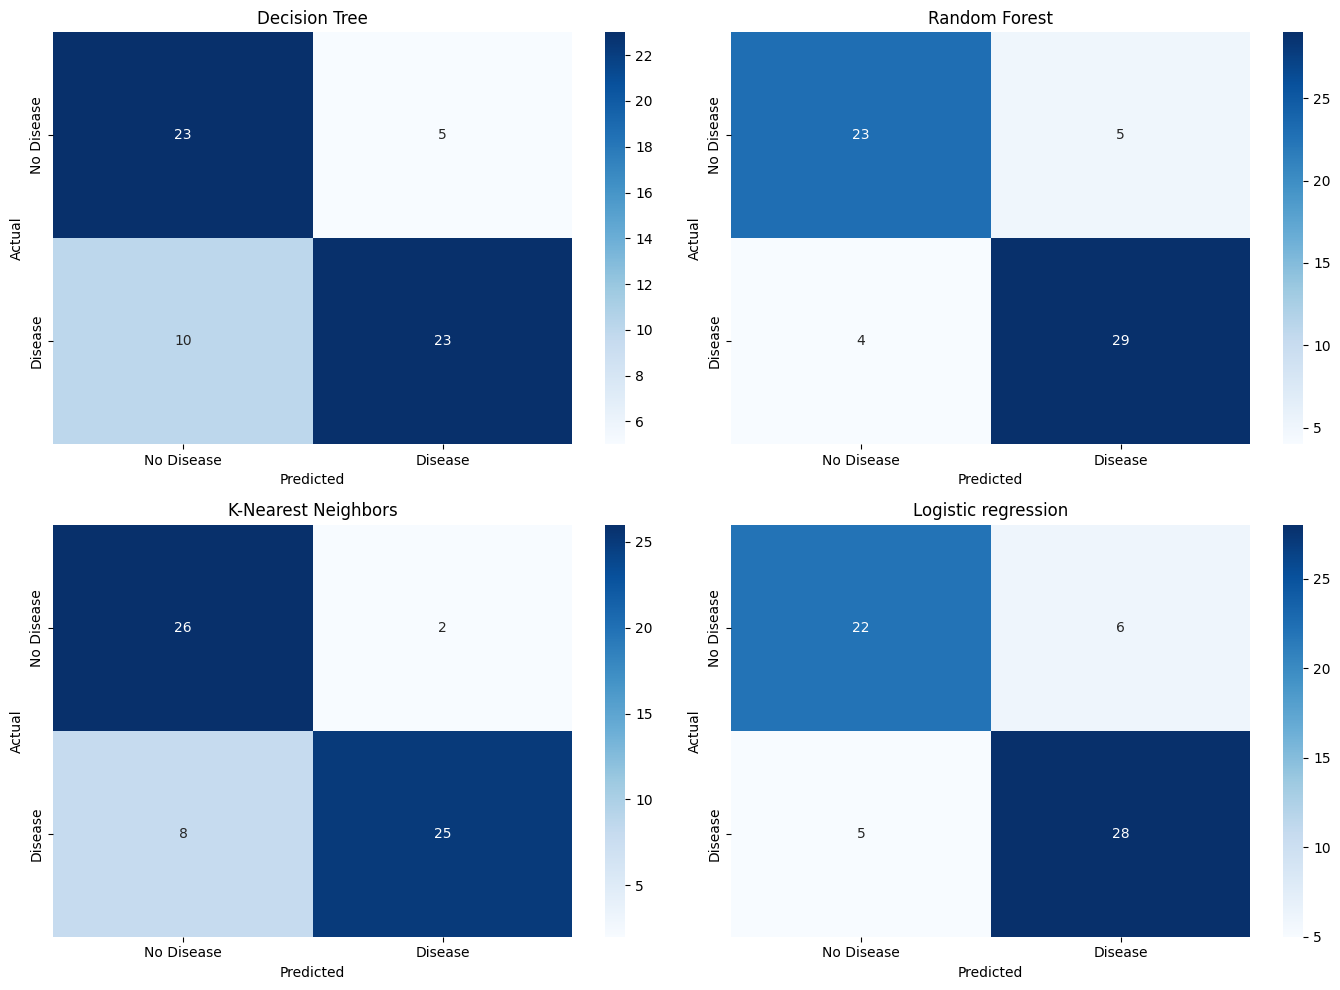

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Generate the confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr2)
cm_dt = confusion_matrix(y_test, y_pred_dt2)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_knn = confusion_matrix(y_test, y_pred_knn)


# Plot the confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LR
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[1, 1].set_title('Logistic regression')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0, 0].set_title('Decision Tree')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0, 1].set_title('Random Forest')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# K-Nearest Neighbors
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[1, 0].set_title('K-Nearest Neighbors')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')


plt.tight_layout()
plt.show()

## FINAL RESULTS

In [62]:

# Extract the relevant metrics from each classification report and convert to percentage with one decimal place
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'Precision (%)': [
        f"{storage_lr['weighted avg']['precision'] * 100:.1f}",
        f"{storage_dt['weighted avg']['precision'] * 100:.1f}",
        f"{storage_rf['weighted avg']['precision'] * 100:.1f}",
        f"{storage_knn['weighted avg']['precision'] * 100:.1f}"
    ],
    'Recall (%)': [
        f"{storage_lr['weighted avg']['recall'] * 100:.1f}",
        f"{storage_dt['weighted avg']['recall'] * 100:.1f}",
        f"{storage_rf['weighted avg']['recall'] * 100:.1f}",
        f"{storage_knn['weighted avg']['recall'] * 100:.1f}"
    ],
    'Recall (%)': [
        f"{storage_lr['weighted avg']['recall'] * 100:.1f}",
        f"{storage_dt['weighted avg']['recall'] * 100:.1f}",
        f"{storage_rf['weighted avg']['recall'] * 100:.1f}",
        f"{storage_knn['weighted avg']['recall'] * 100:.1f}"
    ],
    'F1 Score (%)': [
        f"{storage_lr['weighted avg']['f1-score'] * 100:.1f}",
        f"{storage_dt['weighted avg']['f1-score'] * 100:.1f}",
        f"{storage_rf['weighted avg']['f1-score'] * 100:.1f}",
        f"{storage_knn['weighted avg']['f1-score'] * 100:.1f}"
    ],
        'Recall Positive Class (%)': [
        f"{storage_lr['1']['recall'] * 100:.1f}",  # Assuming '1' is the positive class
        f"{storage_dt['1']['recall'] * 100:.1f}",
        f"{storage_rf['1']['recall'] * 100:.1f}",
        f"{storage_knn['1']['recall'] * 100:.1f}"
    ]
}
# Create a DataFrame
results_df = pd.DataFrame(metrics)

# Display the table
print(results_df)

# Optionally, display the table in a more readable format if using Jupyter Notebook
from IPython.display import display
display(results_df)

                 Model Precision (%) Recall (%) F1 Score (%)  \
0  Logistic Regression          82.0       82.0         81.9   
1        Decision Tree          76.4       75.4         75.4   
2        Random Forest          85.2       85.2         85.2   
3                  KNN          85.2       83.6         83.6   

  Recall Positive Class (%)  
0                      84.8  
1                      69.7  
2                      87.9  
3                      75.8  


,Model,Precision (%),Recall (%),F1 Score (%),Recall Positive Class (%)
0,Logistic Regression,82.0,82.0,81.9,84.8
1,Decision Tree,76.4,75.4,75.4,69.7
2,Random Forest,85.2,85.2,85.2,87.9
3,KNN,85.2,83.6,83.6,75.8


## ROC CURVE 

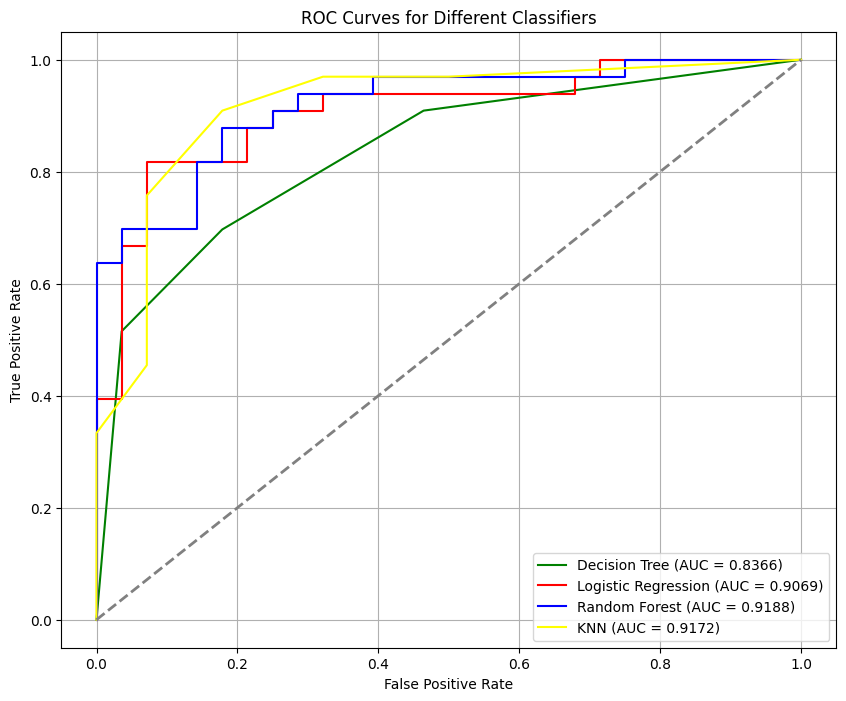

In [63]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the test set for each classifier
y_pred_proba_dt = dt_2ndversion.predict_proba(X_test)[:, 1]
y_pred_proba_lr = LR_model.predict_proba(X_test)[:, 1]
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_proba_knn = best_knn.predict_proba(X_test)[:, 1]

# Calculate the AUC scores
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

# Plot the ROC curves
plt.figure(figsize=(10, 8))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', color='green')

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='red')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='blue')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})', color='yellow')

# Plot the diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Add labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Classifiers')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## 4. MODEL VALIDATION/EVALUATION REGRESSION

### LINEAR REGRESSION

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

# Define the features (X) and target (y)
X = final_df_reg.drop(columns=['thalach'])
#X = MinMaxScaler().fit_transform(X[list_numerical_without_thalach])

y = final_df_reg['thalach']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the linear regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr_model.predict(X_test)

# Calculate evaluation metrics
mse_lr_simple = mean_squared_error(y_test, y_pred)
mae_lr_simple = mean_absolute_error(y_test, y_pred)
mmse_lr_simple = root_mean_squared_error(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse_lr_simple}")
print(f"Mean Absolute Error (MAE): {mae_lr_simple}")
print(f"Root Mean Squared Error (RMSE): {mmse_lr_simple}")


Mean Squared Error (MSE): 318.4769238004894
Mean Absolute Error (MAE): 13.950115291997106
Root Mean Squared Error (RMSE): 17.845921769426464


### LINEAR REGRESSION WITH CROSS VALIDATION

In [65]:
from sklearn.model_selection import cross_val_score


# Create the linear regression model
lr_model = LinearRegression()

# Perform cross-validation for MSE
cv_scores_mse = cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores_mse.mean()

# Perform cross-validation for MAE
cv_scores_mae = cross_val_score(lr_model, X, y, cv=5, scoring='neg_mean_absolute_error')
mean_cv_mae = -cv_scores_mae.mean()

# Calculate the RMSE (Root Mean Squared Error) from MSE
mean_cv_rmse = mean_cv_mse ** 0.5

# Print the cross-validation scores
print(f"Cross-Validation Mean Squared Error (MSE): {mean_cv_mse:.4f}")
print(f"Cross-Validation Mean Absolute Error (MAE): {mean_cv_mae:.4f}")
print(f"Cross-Validation Root Mean Squared Error (RMSE): {mean_cv_rmse:.4f}")


Cross-Validation Mean Squared Error (MSE): 378.6469
Cross-Validation Mean Absolute Error (MAE): 15.1805
Cross-Validation Root Mean Squared Error (RMSE): 19.4589


### RIDGE

In [66]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

# Define the features (X) and target (y)
X = final_df_reg.drop(columns=['thalach'])
#X = MinMaxScaler().fit_transform(X[list_numerical_without_thalach])

y = final_df_reg['thalach']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the linear regression model
ridge_model = Ridge(alpha=0.5)

# Fit the model to the training data
ridge_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = ridge_model.predict(X_test)

# Calculate evaluation metrics
mse_ridge_simple = mean_squared_error(y_test, y_pred)
mae_ridge_simple = mean_absolute_error(y_test, y_pred)
mmse_ridge_simple = root_mean_squared_error(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {mse_ridge_simple}")
print(f"Mean Absolute Error (MAE): {mae_ridge_simple}")
print(f"Root Mean Squared Error (RMSE): {mmse_ridge_simple}")

Mean Squared Error (MSE): 317.8848596796775
Mean Absolute Error (MAE): 13.92925484014991
Root Mean Squared Error (RMSE): 17.82932583357199


### RIDGE WITH CV

In [67]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Create the Ridge regression model
ridge_model = Ridge()

# Define the hyperparameter grid for Ridge regression
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1, 10, 25, 50, 75, 100]
}

# Create the GridSearchCV object
grid_search_ridge = GridSearchCV(ridge_model, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the model to the training data
grid_search_ridge.fit(X_train, y_train)

# Get the best model and hyperparameters
best_ridge_model = grid_search_ridge.best_estimator_
best_ridge_params = grid_search_ridge.best_params_

# Make predictions on the test data
y_pred_ridge = best_ridge_model.predict(X_test)

# Calculate evaluation metrics
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
# Print the evaluation metrics and best hyperparameters
print(f"Best Hyperparameters for Ridge Regression: {best_ridge_params}")
print(f"Mean Squared Error (MSE): {mse_ridge}")
print(f"Mean Absolute Error (MAE): {mae_ridge}")
print(f"Root Mean Squared Error (RMSE): {mmse_ridge}")

Best Hyperparameters for Ridge Regression: {'alpha': 25}
Mean Squared Error (MSE): 319.6260479024638
Mean Absolute Error (MAE): 13.686376819443824
Root Mean Squared Error (RMSE): 17.87808848569846


In [68]:
import pandas as pd
from IPython.display import display

# Create a dictionary with the statistics of the four models
model_statistics = {
    'Model': ['Linear Regression','Linear Regression with cv','Ridge Regression', 'Ridge with cv'],
    'MSE': [mse_lr_simple, mean_cv_mse, mse_ridge_simple, mse_ridge],
    'MAE': [mae_lr_simple, mean_cv_mae, mae_ridge_simple, mae_ridge_simple],
    'RMSE': [mmse_lr_simple, mean_cv_mae, mmse_ridge_simple, mmse_ridge]
}

# Create a DataFrame from the dictionary
model_statistics_df = pd.DataFrame(model_statistics)

# Display the table
print(model_statistics_df)

# Optionally, display the table in a more readable format if using Jupyter Notebook
display(model_statistics_df)

                       Model         MSE        MAE       RMSE
0          Linear Regression  318.476924  13.950115  17.845922
1  Linear Regression with cv  378.646943  15.180501  15.180501
2           Ridge Regression  317.884860  13.929255  17.829326
3              Ridge with cv  319.626048  13.929255  17.878088


,Model,MSE,MAE,RMSE
0,Linear Regression,318.476924,13.950115,17.845922
1,Linear Regression with cv,378.646943,15.180501,15.180501
2,Ridge Regression,317.884860,13.929255,17.829326
3,Ridge with cv,319.626048,13.929255,17.878088
